In [6]:
# Import libraries
import os
import re
import logging
from datetime import datetime
from tqdm.notebook import tqdm

import img_seq_to_tiff
import align_images

# Define project paths
external_drive_path = '/mnt/d'
DIC_folder_path = os.path.join(external_drive_path, 'DIC')
raw_data_path = os.path.join(DIC_folder_path, 'DATA_DIC_RAW')
data_dic_processed_path = os.path.join(DIC_folder_path, 'DATA_DIC_PROCESSED')

tiff_3d_output_path = os.path.join(data_dic_processed_path, '3D_TIFF_RAW')
tiff_3d_aligned_output_raw_path = os.path.join(data_dic_processed_path, 'ALIGNED_TIFF_RAW')
tiff_3d_aligned_output_path = os.path.join(data_dic_processed_path, '3D_TIFF_ALIGNED')
dvc_output_path = os.path.join(data_dic_processed_path, 'DVC_OUTPUT')

filtered_path = 'filtered'
strain_filtered_path = 'strain_filtered'

# Configure logging
logging.basicConfig(
    filename='DIC_analysis.log',
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)

# Make sure the SSD drive is correctly mounted
if os.path.exists(external_drive_path):
    if os.listdir(external_drive_path) == []:
        print(f"External drive at {external_drive_path} is empty, plese mount with: \n\"sudo mount -t drvfs D: /mnt/d\" \nand rerun the cell...")
    else:
        print(f"Connection to SSD disk at {external_drive_path} is successful.")
else:
    print(f"Failed to connect to SSD disk at {external_drive_path}, try mounting with 'sudo mount -t drvfs D: /mnt/d'...")

Connection to SSD disk at /mnt/d is successful.


In [7]:
# Define helper functions

def get_file_desc_from_path(file_name):
    pattern = r'\d+_(ref|load)'
    match = re.search(pattern, file_name)

    if match:
        extracted_text = match.group(0)
        return extracted_text
    else:
        raise Exception(f"No usable regex match found for naming 3D tiff file from path: {file_name}")

def get_folders(path):
    folders = [f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f))]
    return folders

def log_function_call(func):
    def wrapper(*args, **kwargs):
        start_time = datetime.now()
        logging.info(f"Function {func.__name__} started with args: {args}, kwargs: {kwargs}")
        
        result = func(*args, **kwargs)
        
        end_time = datetime.now()
        run_time = end_time - start_time
        run_time_str = str(run_time).split('.')[0]  # Format runtime as hours:minutes:seconds
        logging.info(f"Function {func.__name__} ended with result: {result}")
        logging.info(f"Function {func.__name__} runtime: {run_time_str}")
        
        return result
    return wrapper

In [8]:
# Define data processing functions

@log_function_call
def create_3d_tiff_from_path(path, save_folder_path):
    """
    Create 3D TIFF from image sequence at path and save it to disk. Handles automatic file naming.
    Args:
        path (path): Path to images to create 3D TIFF from.
    Returns:
        None
    """
    img_seq_to_tiff.create_3d_tiff(path, save_folder_path)

@log_function_call
def create_3d_tiffs_from_paths(paths, save_folder_path):
    """
    Create 3D TIFF for every path in paths and save them to disk. Handles automatic file naming.
    Args:
        paths (list): List of paths to create 3D TIFF from.
    Returns:
        None
    """
    for path in tqdm(paths, desc="Creating 3D TIFFs from paths"):
        directory = os.path.dirname(path)

        # Get the last part of the directory name
        second_last_part = os.path.basename(directory)
        file_name = second_last_part + "_" + get_file_desc_from_path(path) + '.tif'
        out_path = os.path.join(save_folder_path, file_name)
        print(path)
        print(out_path)
        print('----------------')
        create_3d_tiff_from_path(path, out_path)

@log_function_call
def align_images_from_path(ref_folder_path, def_folder_path, save_folder_path, row_range, col_range):
    """
    Align images by shifting. Saves aligned images to save_folder_path.
    Args:
        ref_folder_path (path): Path to reference images.
        def_folder_path (path): Path to deformed images.
        save_folder_path (path): Path to save aligned images.
        row_range (tuple): Range of rows to focus on.
        col_range (tuple): Range of columns to focus on.
    Returns:
        None
    """
    align_images.align(ref_folder_path, def_folder_path, save_folder_path, row_range, col_range)

In [9]:
# List the contents of the directory /mnt/d
contents = os.listdir(external_drive_path)
print(contents)

['System Volume Information', '$RECYCLE.BIN', 'DIC']


In [10]:
# Go through each raw data folder, get a list of folders inside and asign it to data_paths
folders_1 = [f for f in os.listdir(raw_data_path) if os.path.isdir(os.path.join(raw_data_path, f))]

data_paths = []
for folder in folders_1:
    path_2 = os.path.join(raw_data_path, folder)
    folders_2 = [f for f in os.listdir(path_2) if os.path.isdir(os.path.join(path_2, f))]
    
    # Save full path of folder into data_paths
    tmp = []
    for folder_2 in folders_2:
        tmp.append(os.path.join(path_2, folder_2))
    data_paths.append(tmp)

In [6]:
# Create 3D TIFFs from raw ref data
for path_grp in tqdm(data_paths, desc="Processing"):
    path = path_grp[0]
    # Get the directory name of the path
    directory = os.path.dirname(path)

    # Get the last part of the directory name
    basename = os.path.basename(directory)
    save_path_3d_file = os.path.join(tiff_3d_aligned_output_path, basename, basename + "_" + get_file_desc_from_path(path) + '.tif')
    if not os.path.exists(save_path_3d_file):
        create_3d_tiff_from_path(path, save_path_3d_file)

NameError: name 'data_paths' is not defined

In [7]:
# Align images from raw data
for path_grp in data_paths:

    for i, path in tqdm(enumerate(path_grp), desc="Processing", total=len(path_grp)):
        # Don't allign reference with itself
        if i != 0:
            continue
        # Get the directory name of the path
        directory = os.path.dirname(path)

        # Get the last part of the directory name
        basename = os.path.basename(directory)
        save_folder = os.path.join(tiff_3d_aligned_output_raw_path, basename, get_file_desc_from_path(path))
        if not os.path.exists(save_folder):
            align_images_from_path(path_grp[0], path, save_folder, (1400, 1600), (400, 800))
        
        save_path_3d_file = os.path.join(tiff_3d_aligned_output_path, basename, basename + "_" + get_file_desc_from_path(path) + '.tif')
        if not os.path.exists(save_path_3d_file):
            create_3d_tiff_from_path(save_folder, save_path_3d_file)

NameError: name 'data_paths' is not defined

In [11]:
@log_function_call
def dvc_procedures(hws, ns, it, glt, m_x, m_y, m_z, im1, im2, out):
    ldic = f'spam-ldic {im1} {im2} -hws {hws} -ns {ns} -it {it} -glt {glt} -vtk -tif -od {out} -m3 {m_z} {m_y} {m_x}'
    !{ldic}

    # find tsv file in out folder
    tsv_file = None
    for file in os.listdir(out):
        if file.endswith('.tsv'):
            tsv_file = os.path.join(out, file)
            break

    if tsv_file is None:
        raise FileNotFoundError("No .tsv file found in the output directory")

    out_filter = os.path.join(out, filtered_path)

    filter = f'spam-filterPhiField -pf {tsv_file} -fm -F "all" -tif -vtk -od {out_filter}'
    !{filter}

    # find tsv file in out folder
    tsv_file_filtered = None
    for file in os.listdir(out_filter):
        if file.endswith('.tsv'):
            tsv_file_filtered = os.path.join(out_filter, file)
            break

    if tsv_file_filtered is None:
        raise FileNotFoundError("No .tsv file found in the filtered output directory")

    out_strain = os.path.join(out, strain_filtered_path)
    strain = f'spam-regularStrain {tsv_file_filtered} -comp vol dev U -cub -tif -vtk -od {out_strain} -rst 1'
    !{strain}

In [12]:
import tifffile as tiff

data_paths_3d = get_folders(tiff_3d_aligned_output_path)
data_paths_3d_files = []
for folder in data_paths_3d:
    grp = []
    for file in os.listdir(os.path.join(tiff_3d_aligned_output_path, folder)):
        grp.append(os.path.join(tiff_3d_aligned_output_path, folder, file))
    data_paths_3d_files.append(grp)

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import tifffile as tiff
import os
from mpl_toolkits.axes_grid1 import make_axes_locatable
from datetime import datetime
import io

def make_graphs(path, save_path):
    

    # Load the 3D TIFF file
    image_path = path  # Your image path variable
    image = tiff.imread(image_path)
    # print min and max value in image, make sure it's not nan
    # print(np.nanmax(image) - np.nanmin(image))

    # Create the figure with visualizations
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # fig title
    fig.suptitle(f'{os.path.basename(image_path)}', fontsize=16)

    # Calculate middle slices
    z_mid = image.shape[0] // 2
    y_mid = image.shape[1] // 2
    x_mid = image.shape[2] // 2

    # Function to add colorbar to each subplot
    def add_colorbar(im, ax):
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(im, cax=cax)

    # XY plane (Z slice)
    im0 = axes[0].imshow(image[z_mid, :, :], cmap='gray')
    axes[0].set_title(f'XY Plane (Z={z_mid})')
    axes[0].set_xlabel(f'X dimension: {image.shape[2]} pixels')
    axes[0].set_ylabel(f'Y dimension: {image.shape[1]} pixels')
    add_colorbar(im0, axes[0])

    # XZ plane (Y slice)
    im1 = axes[1].imshow(image[:, y_mid, :], cmap='gray')
    axes[1].set_title(f'XZ Plane (Y={y_mid})')
    axes[1].set_xlabel(f'X dimension: {image.shape[2]} pixels')
    axes[1].set_ylabel(f'Z dimension: {image.shape[0]} pixels')
    add_colorbar(im1, axes[1])

    # YZ plane (X slice)
    im2 = axes[2].imshow(image[:, :, x_mid], cmap='gray')
    axes[2].set_title(f'YZ Plane (X={x_mid})')
    axes[2].set_xlabel(f'Y dimension: {image.shape[1]} pixels')
    axes[2].set_ylabel(f'Z dimension: {image.shape[0]} pixels')
    add_colorbar(im2, axes[2])

    # Add overall dimension text
    fig.text(0.5, 0.01, f'Volume dimensions: Z={image.shape[0]}, Y={image.shape[1]}, X={image.shape[2]} pixels', 
            ha='center', fontsize=12)

    plt.tight_layout(rect=[0, 0.03, 1, 0.97])

    # Save figure to a file
    output_image_path = os.path.join(save_path, f"{image_path.split(os.path.sep)[-3]}.png")
    plt.savefig(output_image_path, format='png', dpi=200)

mock_d/DIC/DATA_DIC_PROCESSED/DVC_OUTPUT/60hws_40ns_50it_44glt_3z-3y-3xm_G16057_K13_5_0_ref-G16057_K13_5_3_load/strain_filtered
mock_d/DIC/DATA_DIC_PROCESSED/DVC_OUTPUT/20hws_40ns_50it_44glt_3z-3y-3xm_G16057_K13_5_0_ref-G16057_K13_5_3_load/strain_filtered
mock_d/DIC/DATA_DIC_PROCESSED/DVC_OUTPUT/40hws_40ns_50it_44glt_3z-3y-3xm_G16057_K13_5_0_ref-G16057_K13_5_3_load/strain_filtered


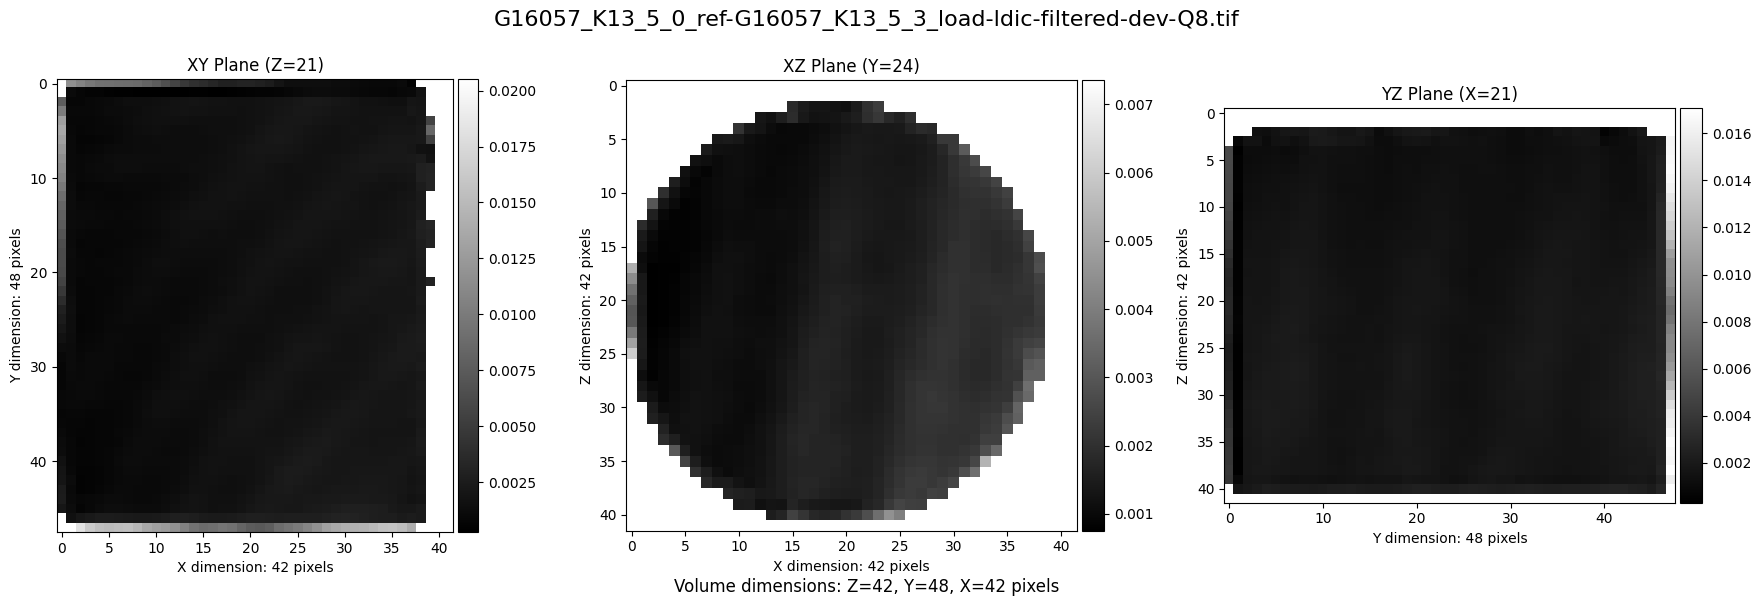

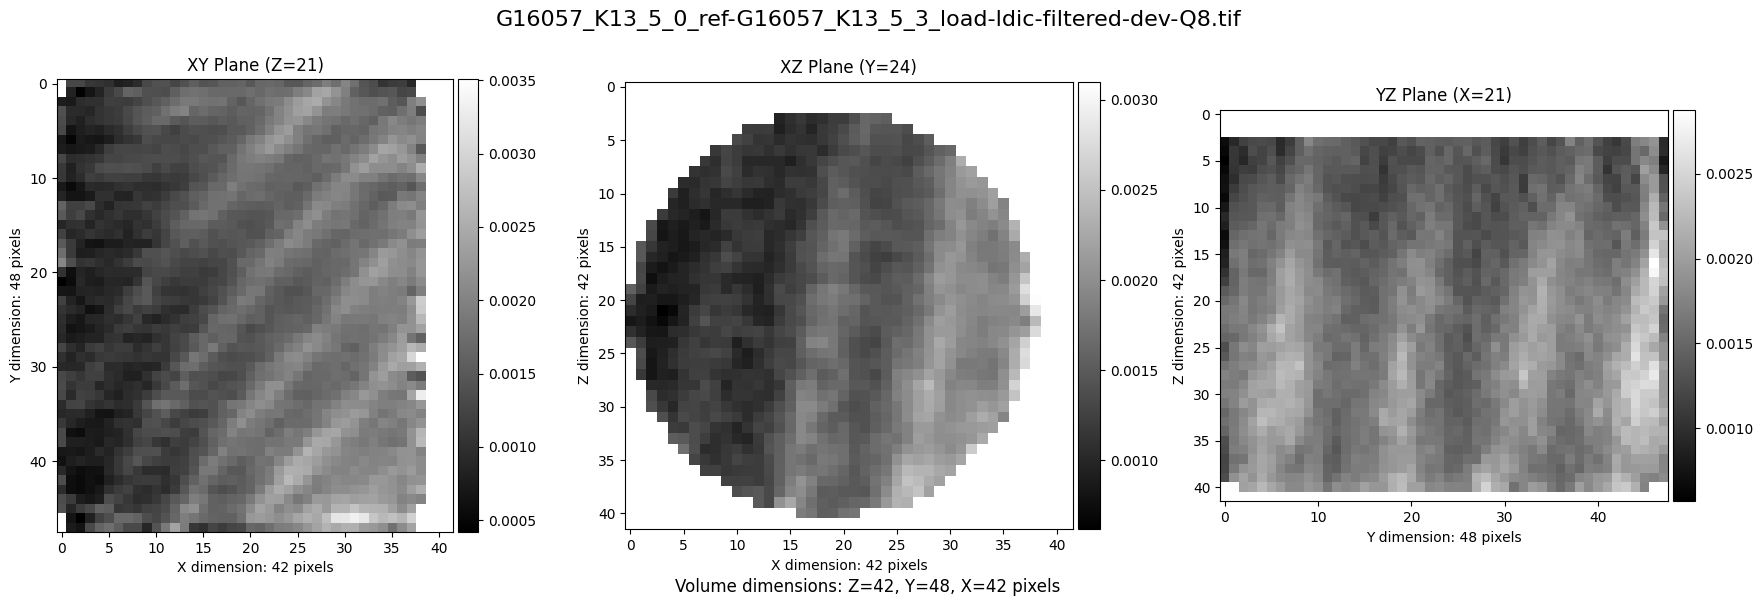

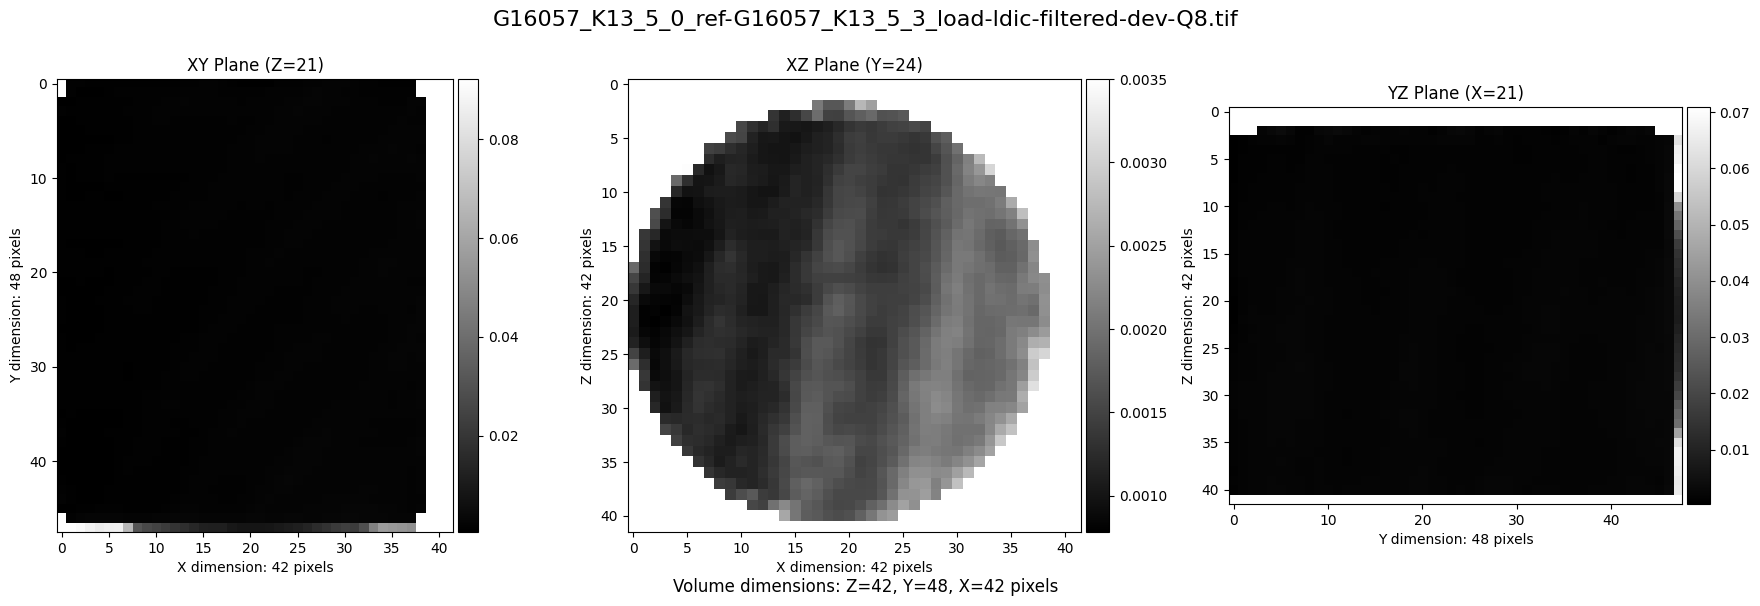

In [49]:
sample = "G16057_K13_5_3_load"
hws = None
ns = 40

dvc_out_files = os.listdir(dvc_output_path)
for file in dvc_out_files:

    if(sample != "" and sample not in file):
        continue
    if(hws != None and f"{hws}hws" not in file):
        continue
    if(ns != None and f"{ns}ns" not in file):
        continue

    if(not os.path.exists(os.path.join(dvc_output_path, file, 'strain_filtered'))):
        continue
    
    filtered_files = os.listdir(os.path.join(dvc_output_path, file, 'strain_filtered'))
    for f in filtered_files:
        if "dev" in f:
            
            # # load the 3D TIFF file
            image_path = os.path.join(dvc_output_path, file, 'strain_filtered', f)  # Your image path variable
            # image = tiff.imread(image_path)[1:,:,:]

            # save plot of middle slices into png
            save_path = os.path.join(dvc_output_path, file, 'strain_filtered')
            make_graphs(image_path, save_path)
            print(save_path)

            break
    

In [14]:
import numpy as np

# Do DVC on all reference - load pairs in data
hws_experiments = [20, 40, 60]
ns_experiments = [80, 60, 40]
it = 50
m_x = 3
m_y = 3
m_z = 3

for files in tqdm(data_paths_3d_files, desc="TOTAL PROGRESS"):

    im1 = None  # reference image
    for file in files:
        if 'ref' in file:
            im1 = file
            break
    
    for file in tqdm(files, desc="FILES PROCESSED"):
        if 'ref' in file:
            continue

        im2 = file

        p = os.path.basename(os.path.dirname(im1))
        a = os.path.join(raw_data_path, p)
        b = os.listdir(a)[0]
        c = os.listdir(os.path.join(a, b))[25]
        d = os.path.join(a, b, c)

        img = tiff.imread(d)
        h, w = img.shape
        img = img[h//2-25:h//2+25, w//2-25:w//2+25]

        # get average intensity of the image
        glt = np.mean(img) + 5

        for hws in hws_experiments:
            for ns in ns_experiments:
                out = os.path.join(dvc_output_path, f"{hws}hws_{ns}ns_{it}it_{round(glt)}glt_{m_z}z-{m_y}y-{m_x}xm_{os.path.basename(im1).replace('.tif', '')}-{os.path.basename(im2).replace('.tif', '')}")
                if os.path.exists(out) and filtered_path in os.listdir(out) and strain_filtered_path in os.listdir(out):
                    continue
                
                dvc_procedures(hws, ns, it, glt, m_x, m_y, m_z, im1, im2, out)
                p = os.path.join(out, strain_filtered_path)
                for file in os.listdir(p):

                    if "dev" in file:
                        d = os.path.join(p, file)
                        make_graphs(d, p)


TOTAL PROGRESS:   0%|          | 0/4 [00:00<?, ?it/s]

FILES PROCESSED:   0%|          | 0/4 [00:00<?, ?it/s]

FILES PROCESSED:   0%|          | 0/4 [00:00<?, ?it/s]

FILES PROCESSED:   0%|          | 0/5 [00:00<?, ?it/s]

FILES PROCESSED:   0%|          | 0/4 [00:00<?, ?it/s]

40hws_60ns_50it_44glt_3z-3y-3xm_G16057_K13_5_0_ref-G16057_K13_5_1_load.png


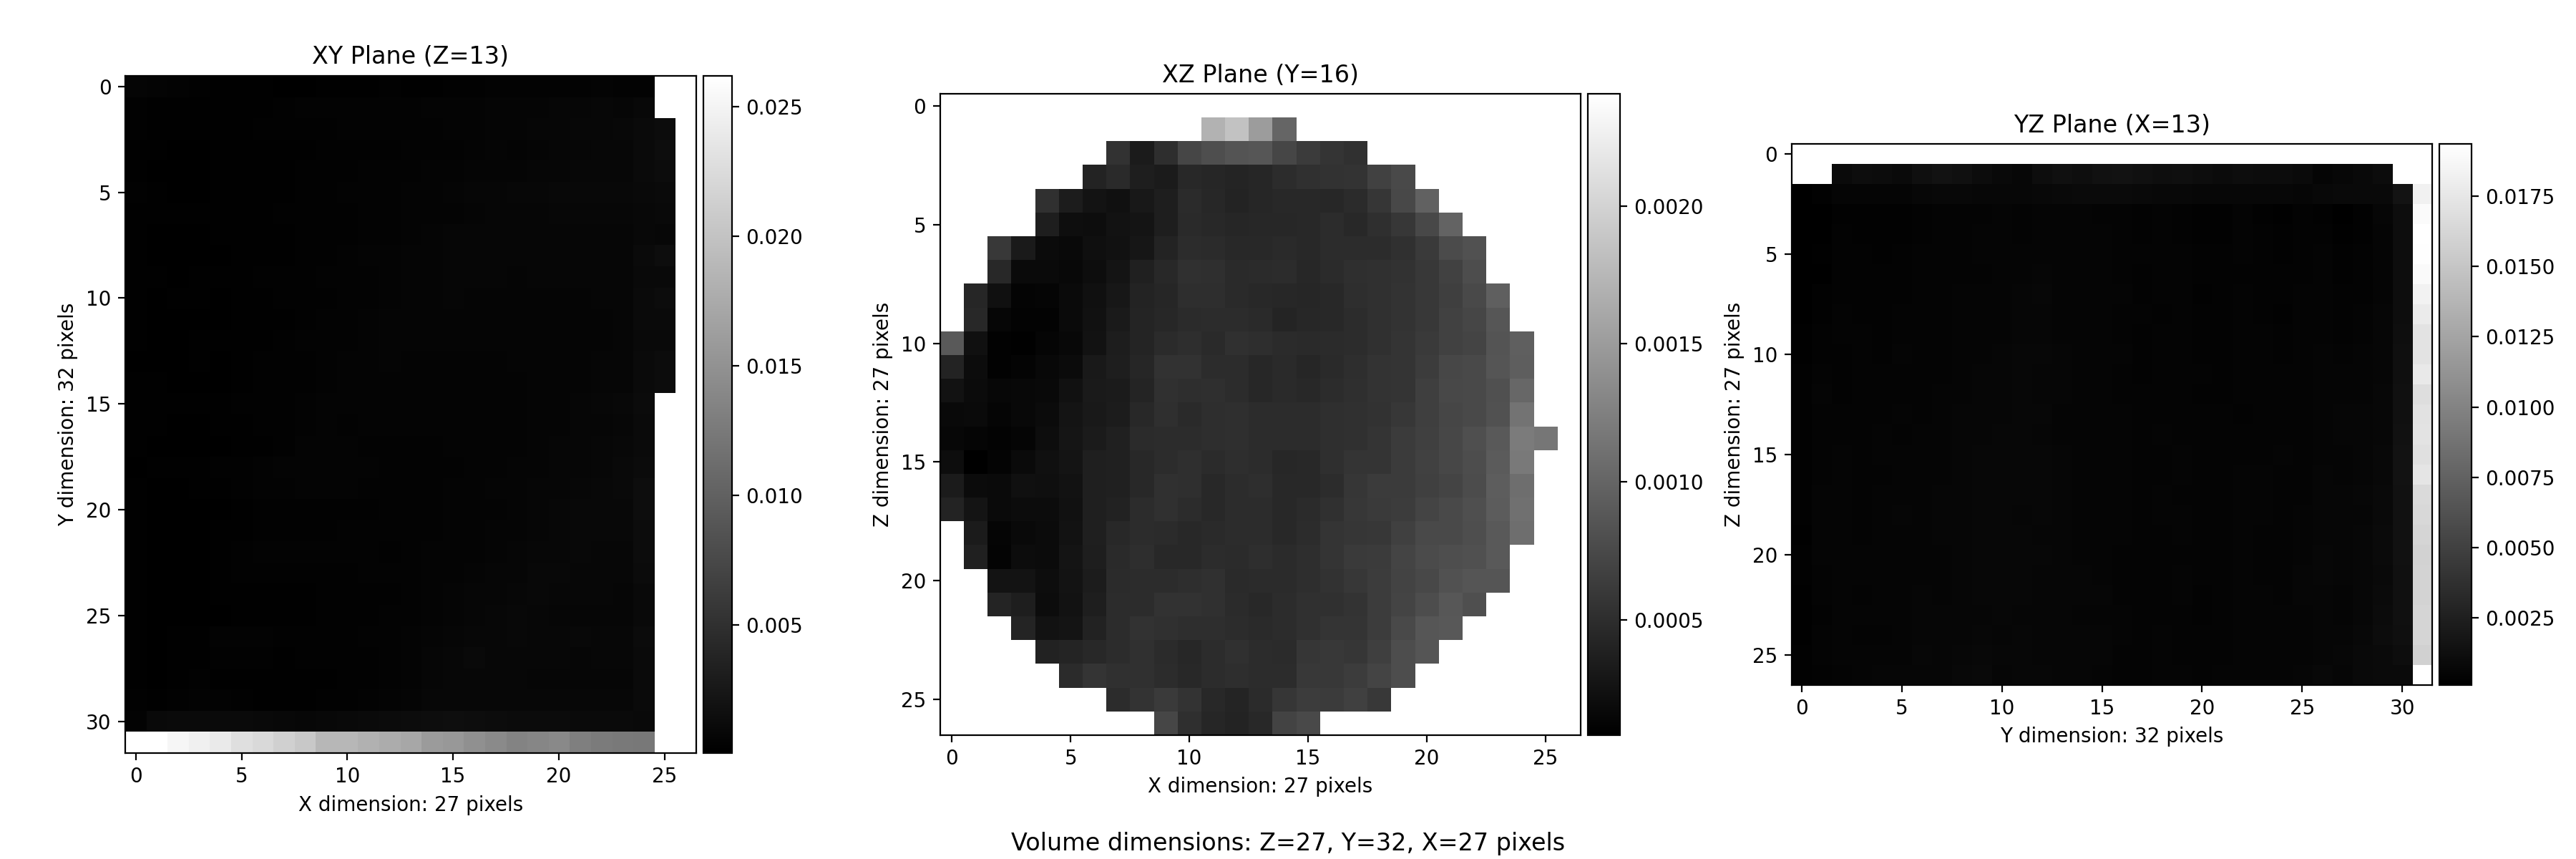

40hws_60ns_50it_44glt_3z-3y-3xm_G16057_K13_5_0_ref-G16057_K13_5_2_load.png


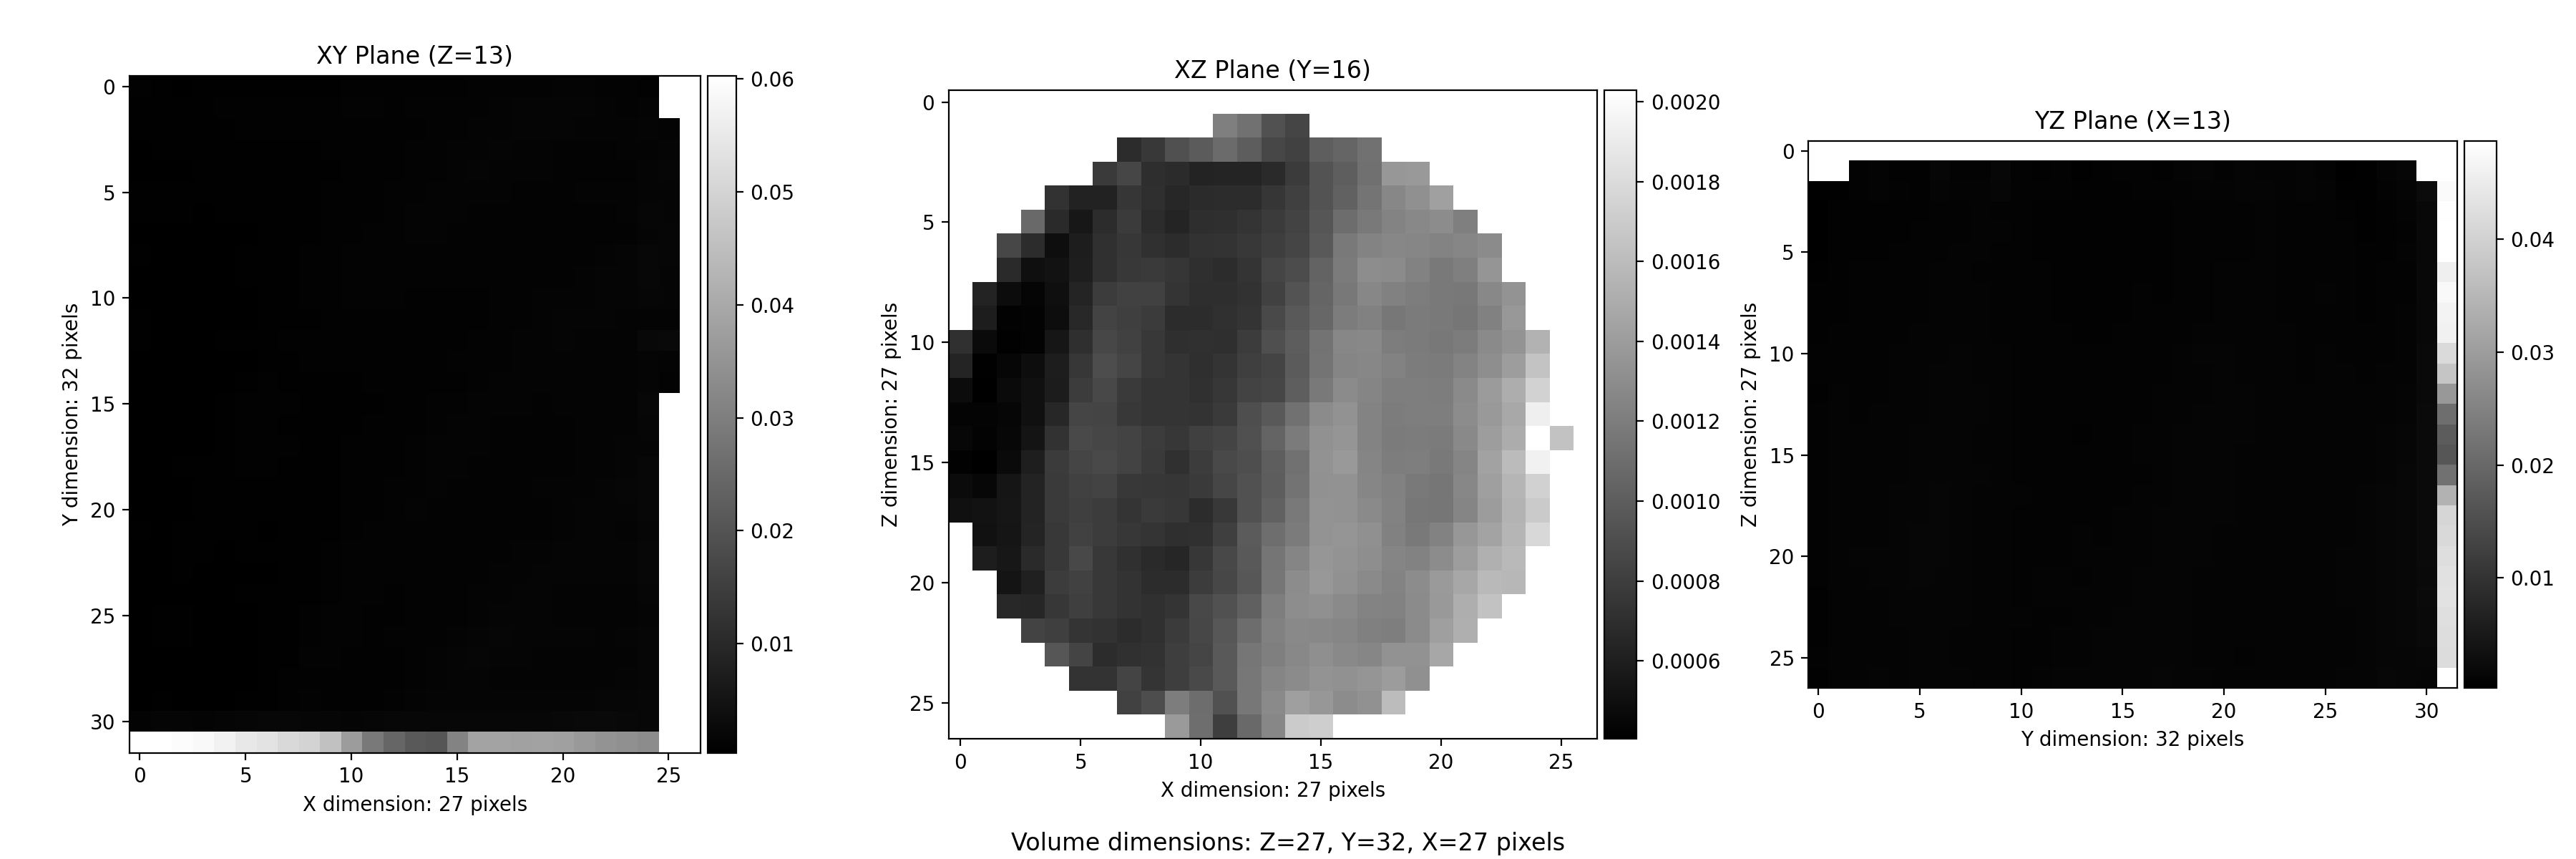

40hws_60ns_50it_44glt_3z-3y-3xm_G16057_K13_5_0_ref-G16057_K13_5_3_load.png


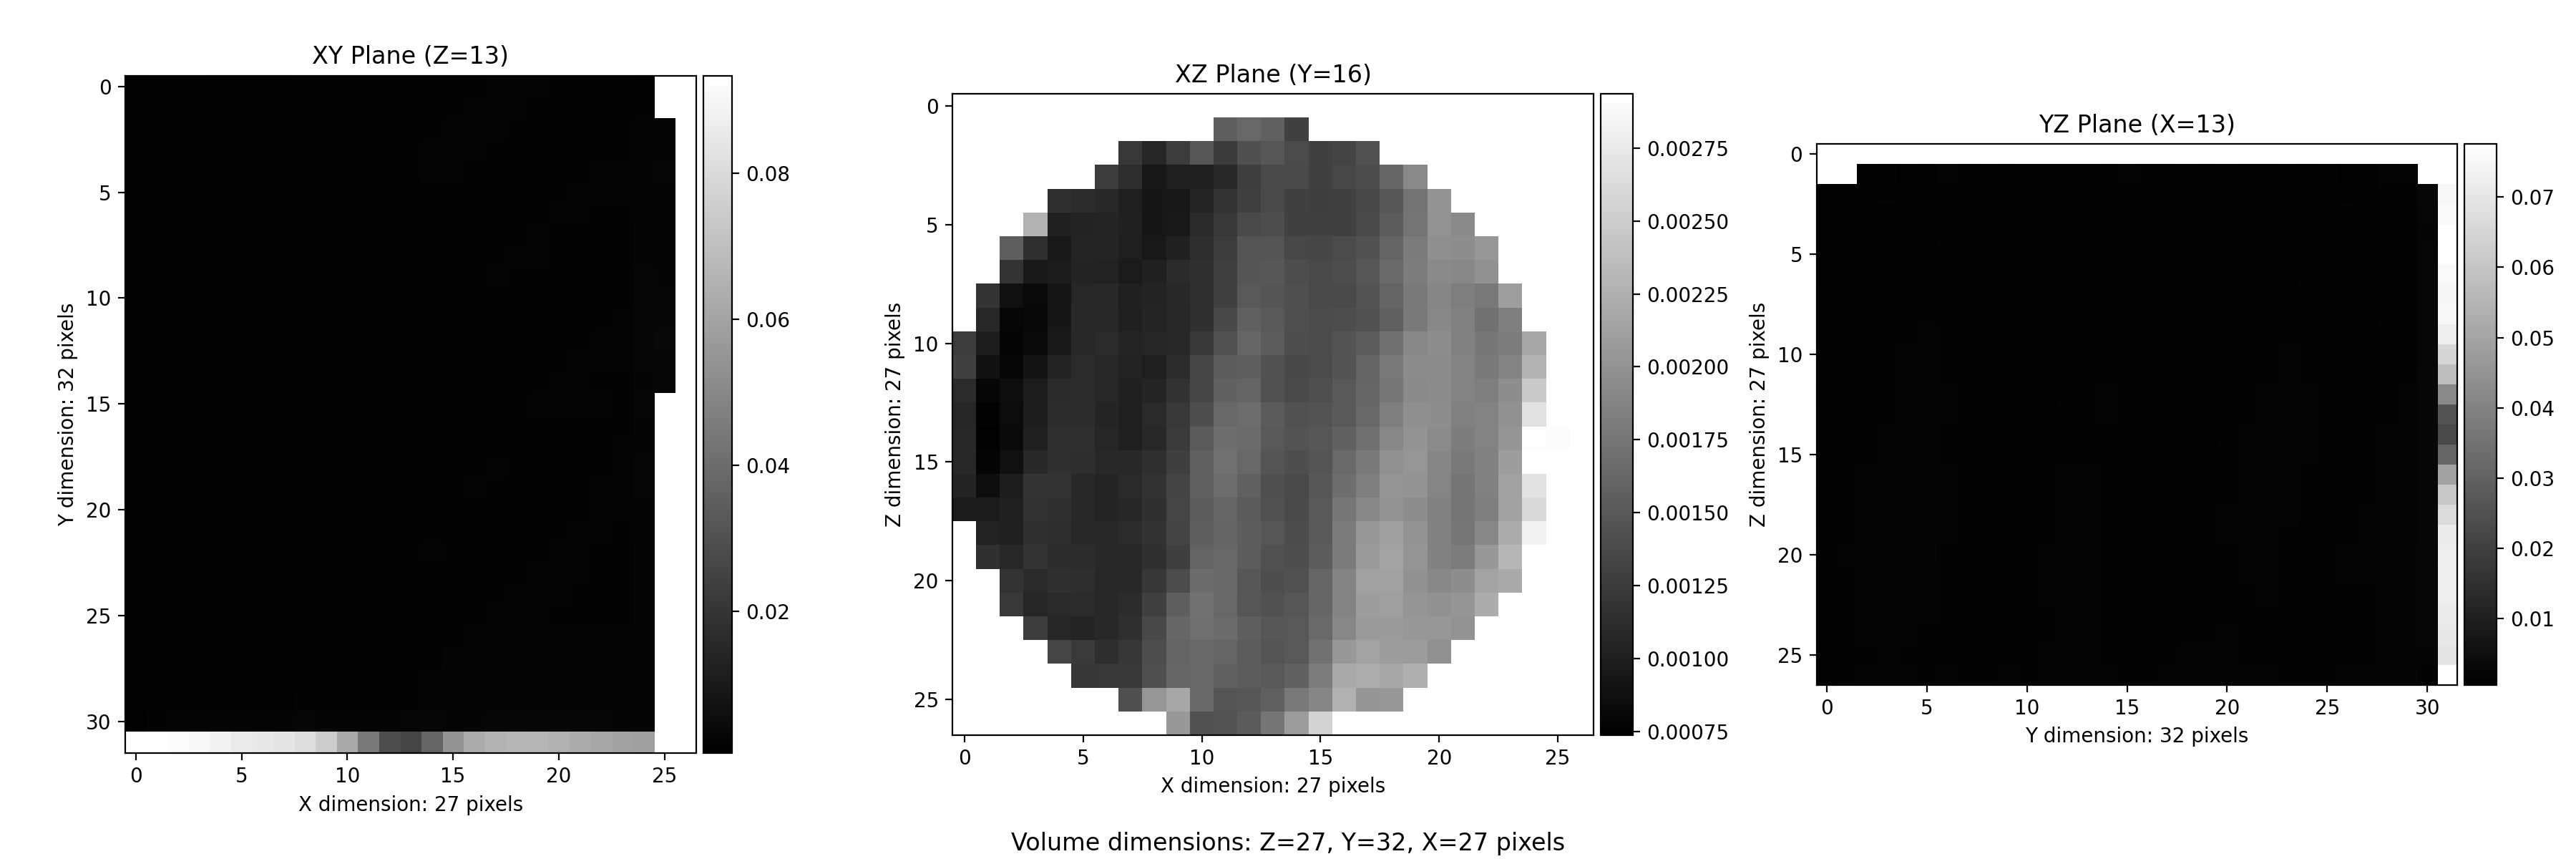

40hws_60ns_50it_47glt_3z-3y-3xm_G16057_P4_5_0_ref-G16057_P4_5_1_load.png


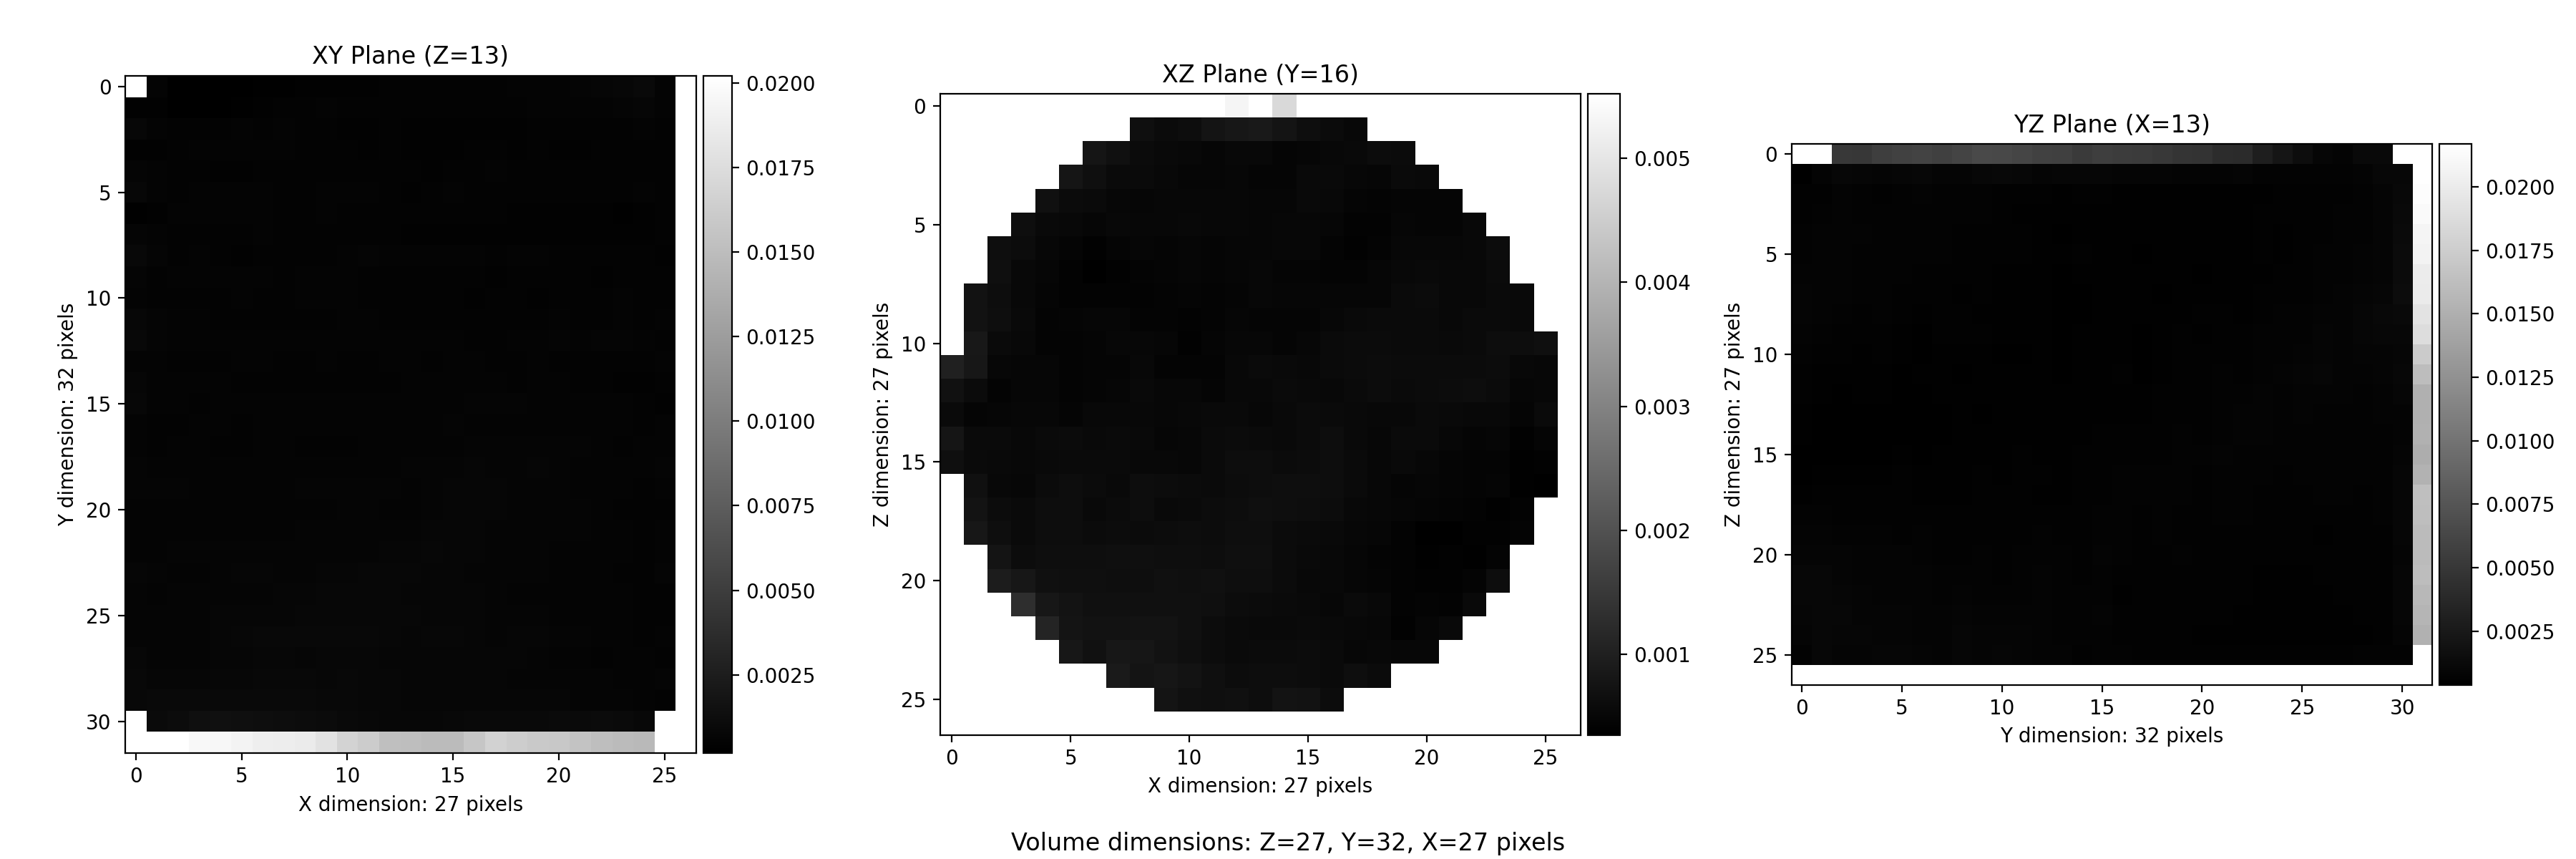

40hws_60ns_50it_47glt_3z-3y-3xm_G16057_P4_5_0_ref-G16057_P4_5_2_load.png


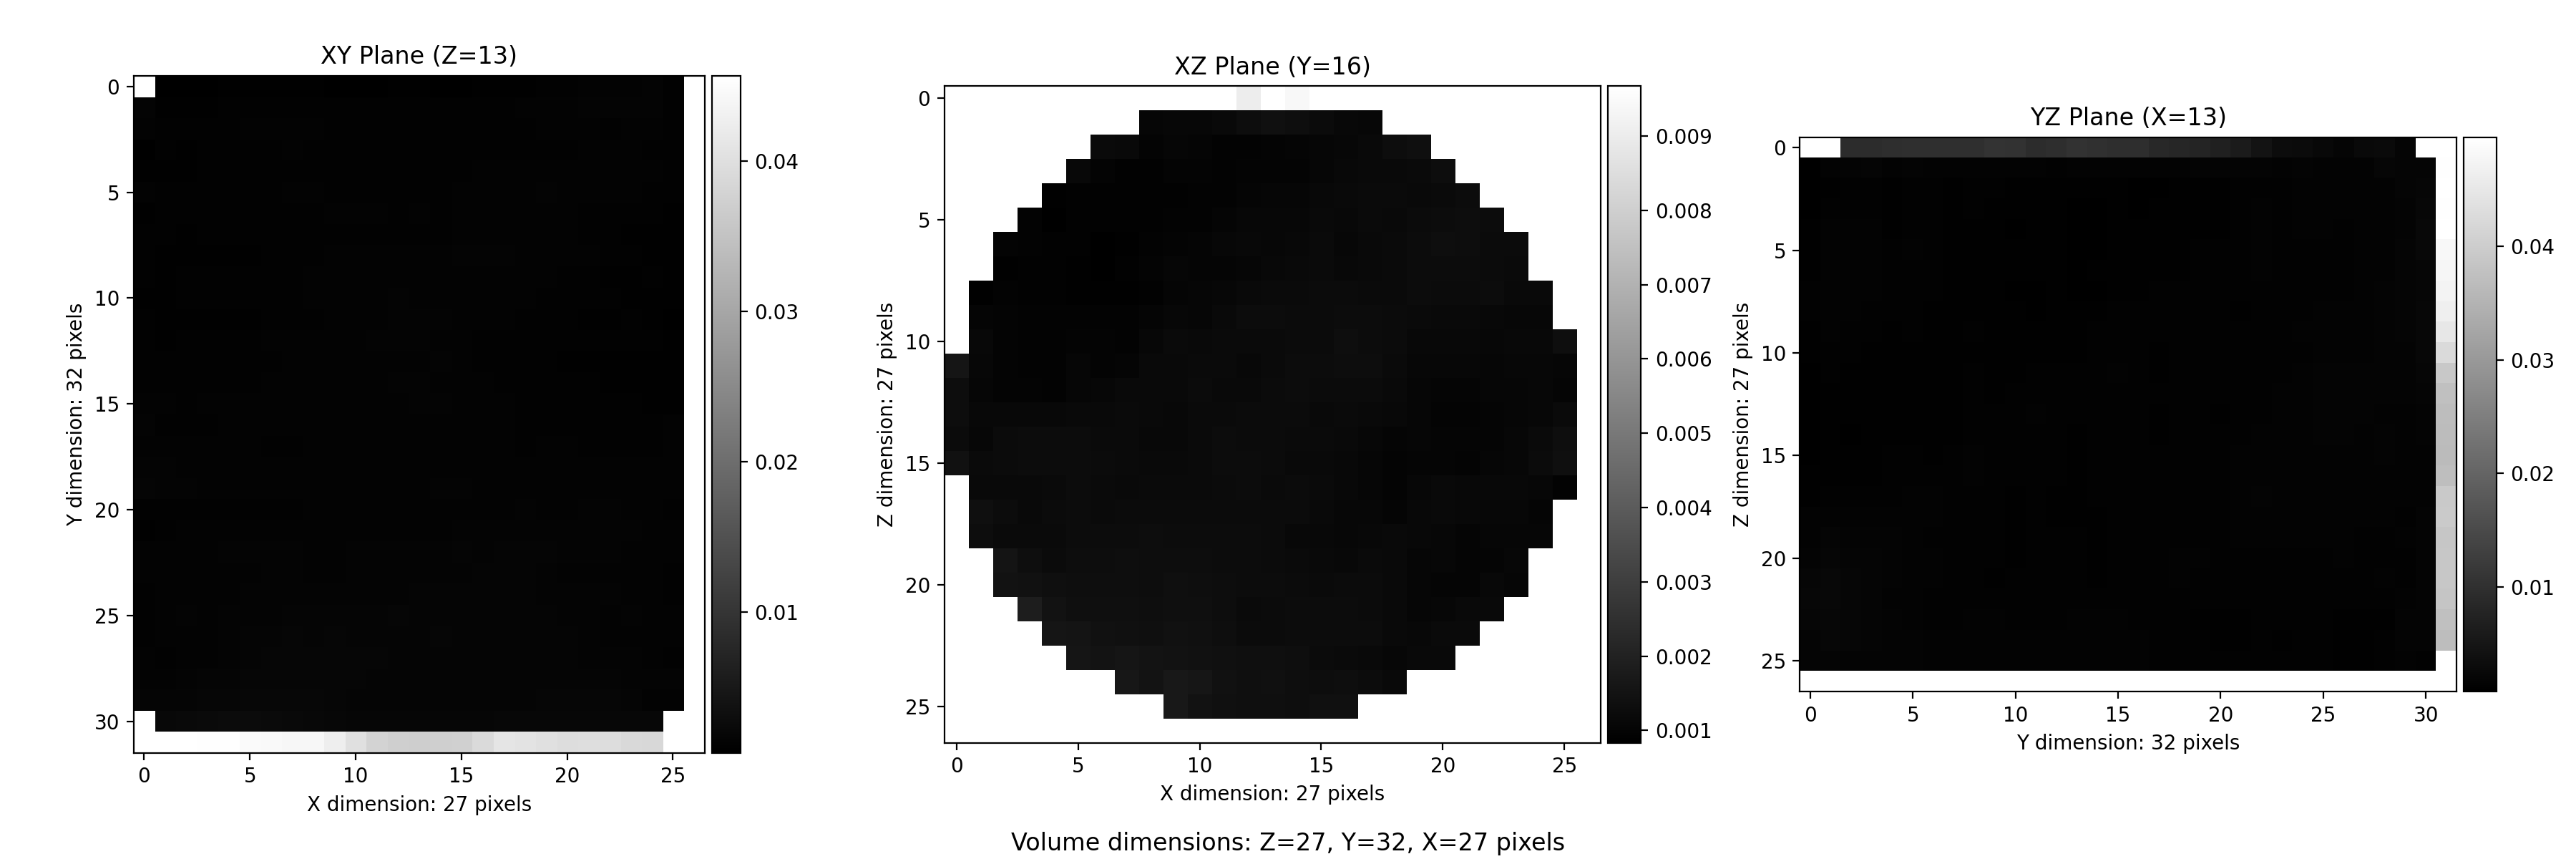

40hws_60ns_50it_47glt_3z-3y-3xm_G16057_P4_5_0_ref-G16057_P4_5_3_load.png


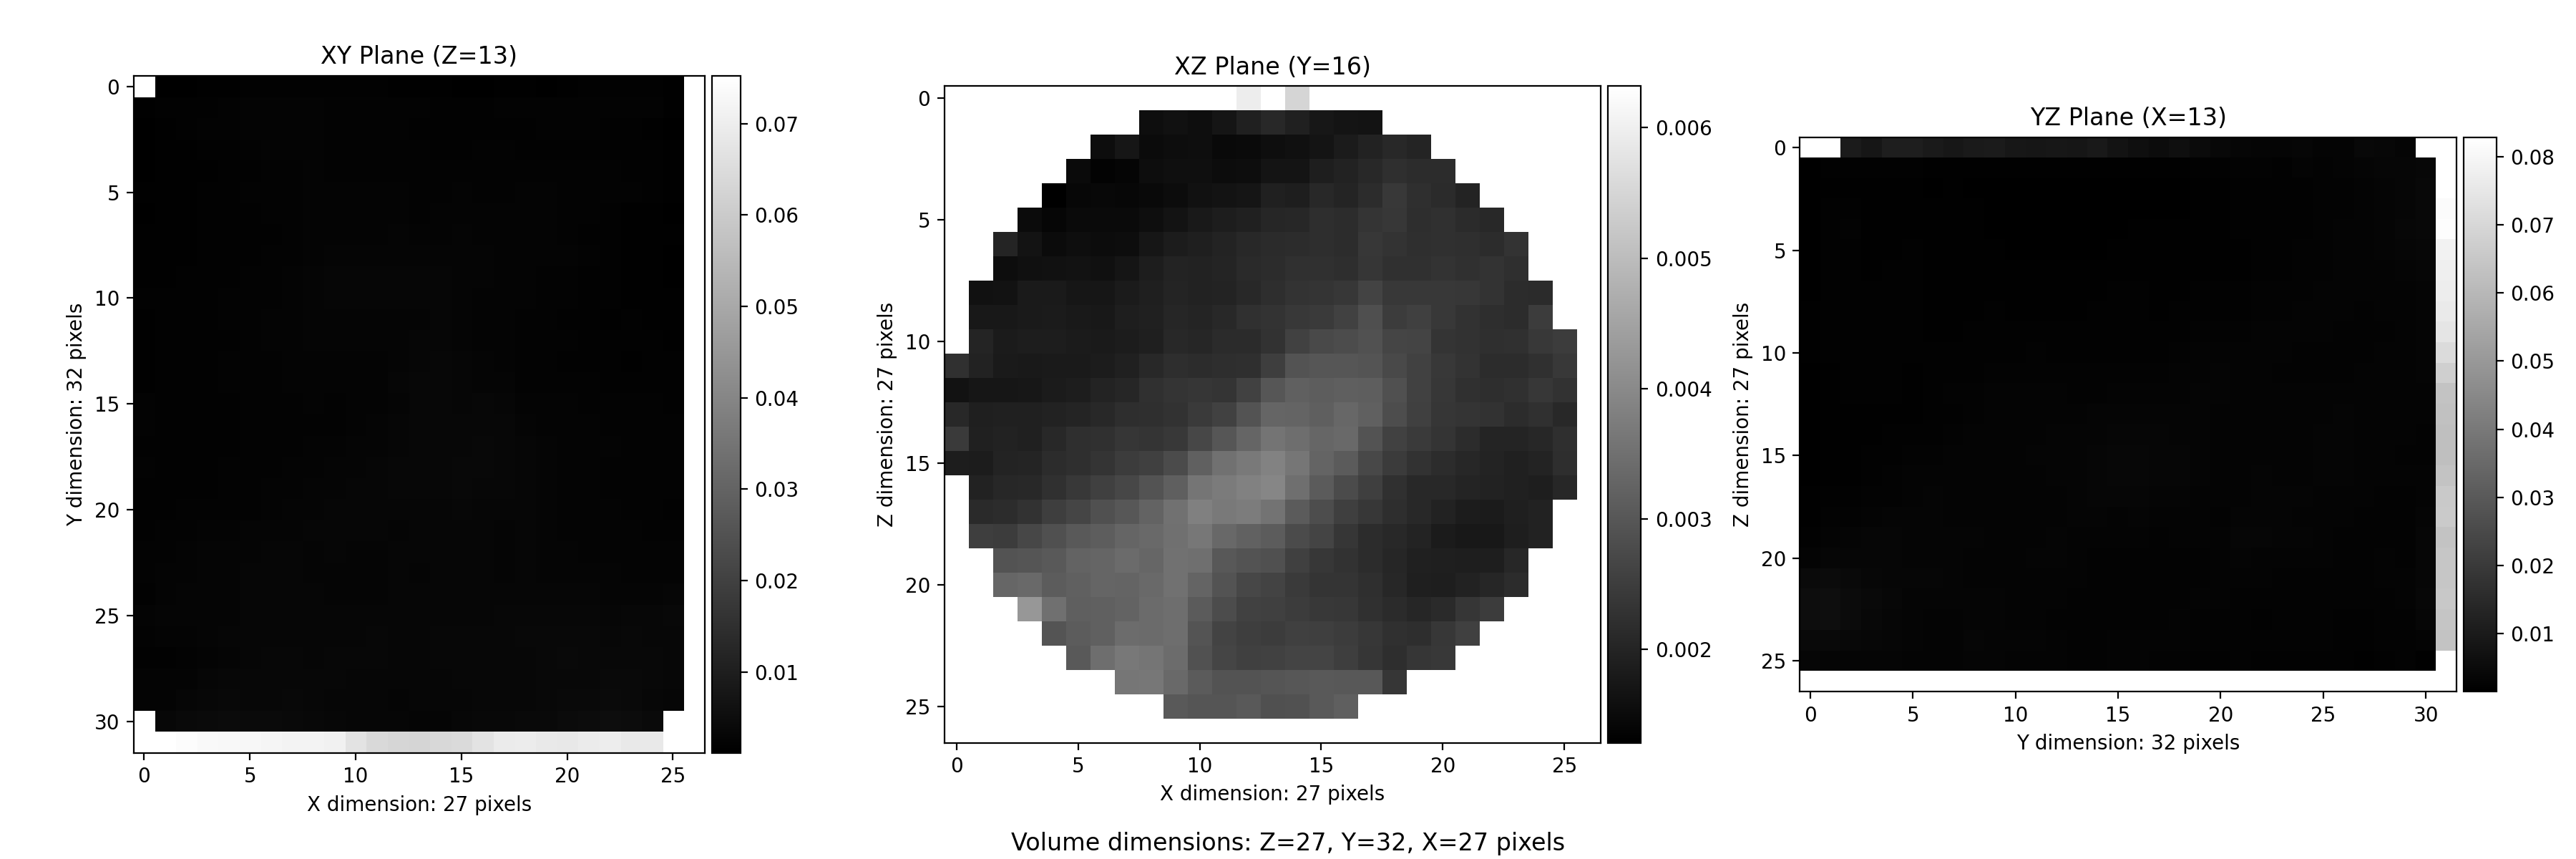

40hws_60ns_50it_63glt_3z-3y-3xm_G16060_K12_5_0_ref-G16060_K12_5_1_load.png


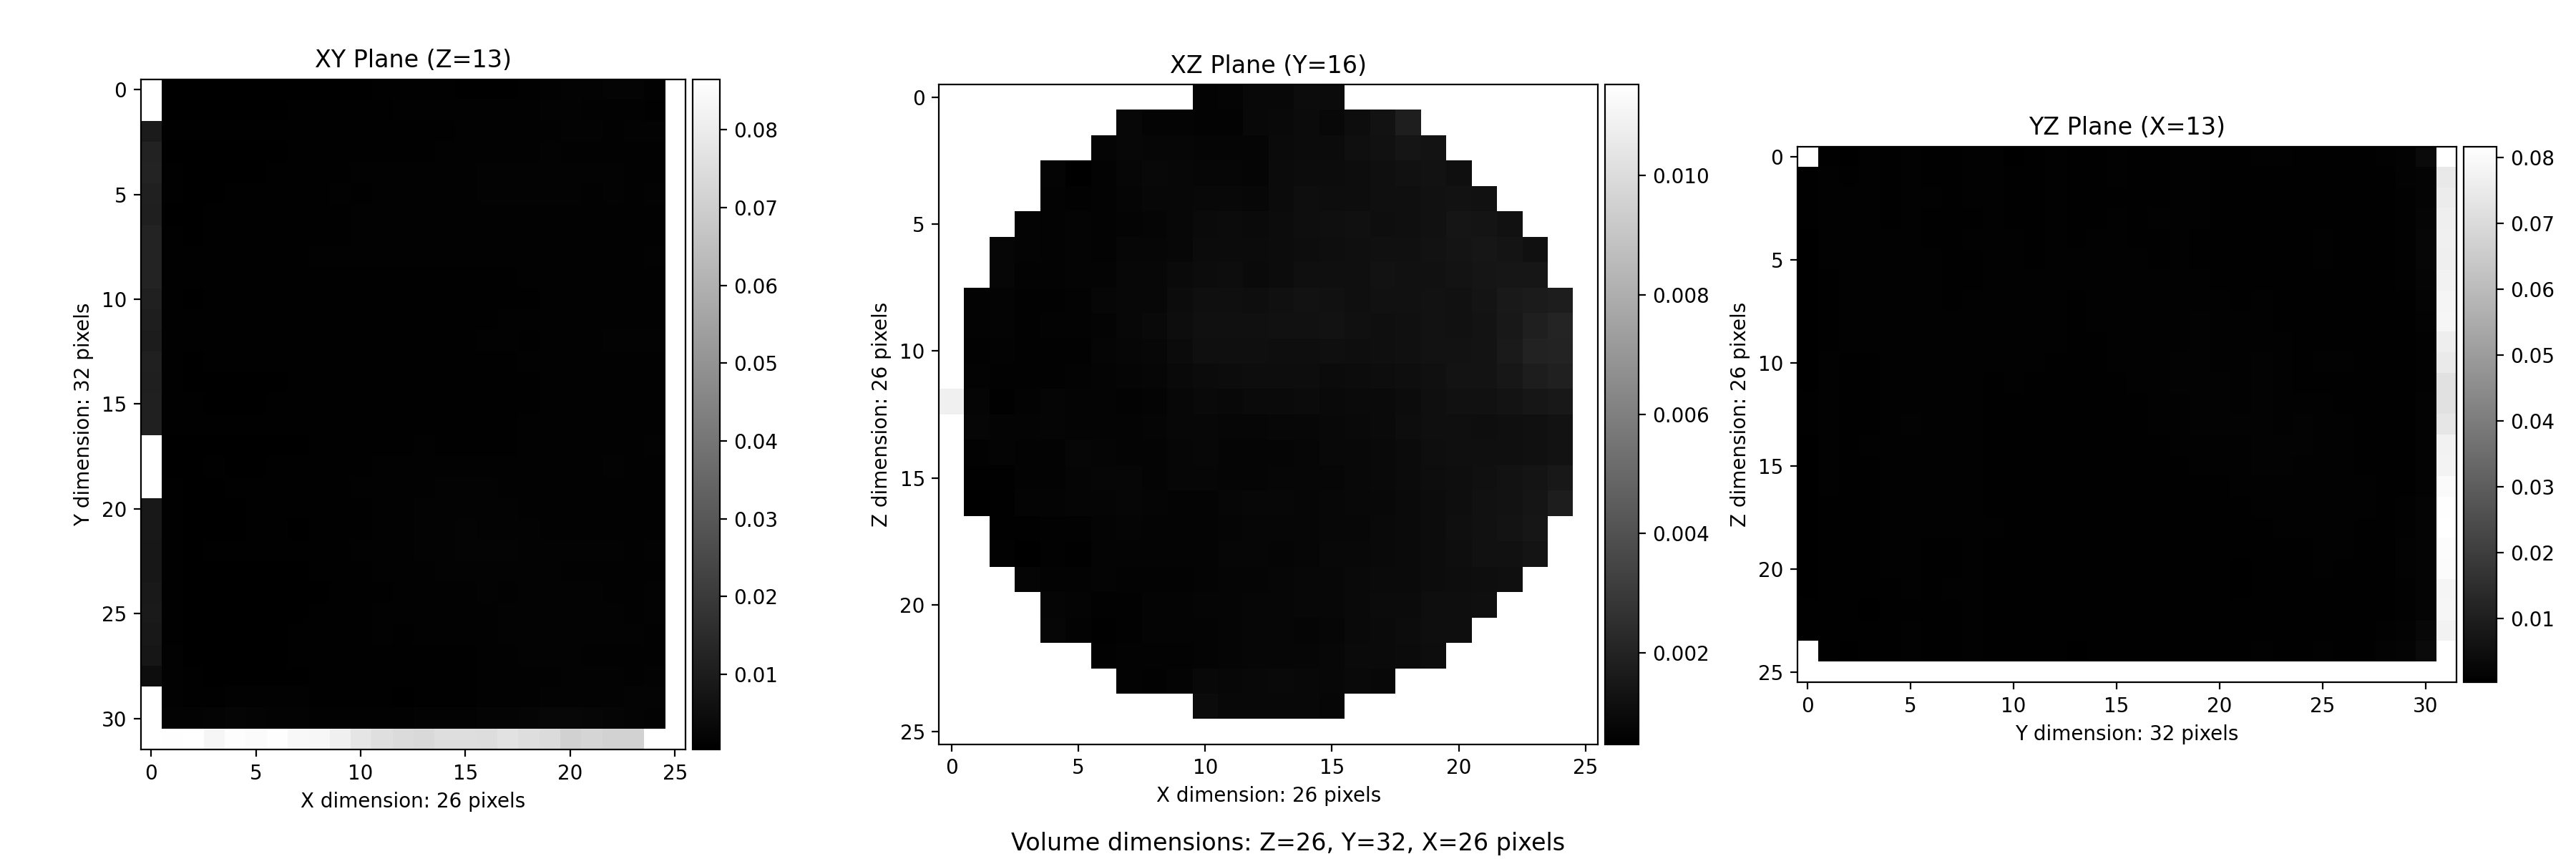

40hws_60ns_50it_63glt_3z-3y-3xm_G16060_K12_5_0_ref-G16060_K12_5_2_load.png


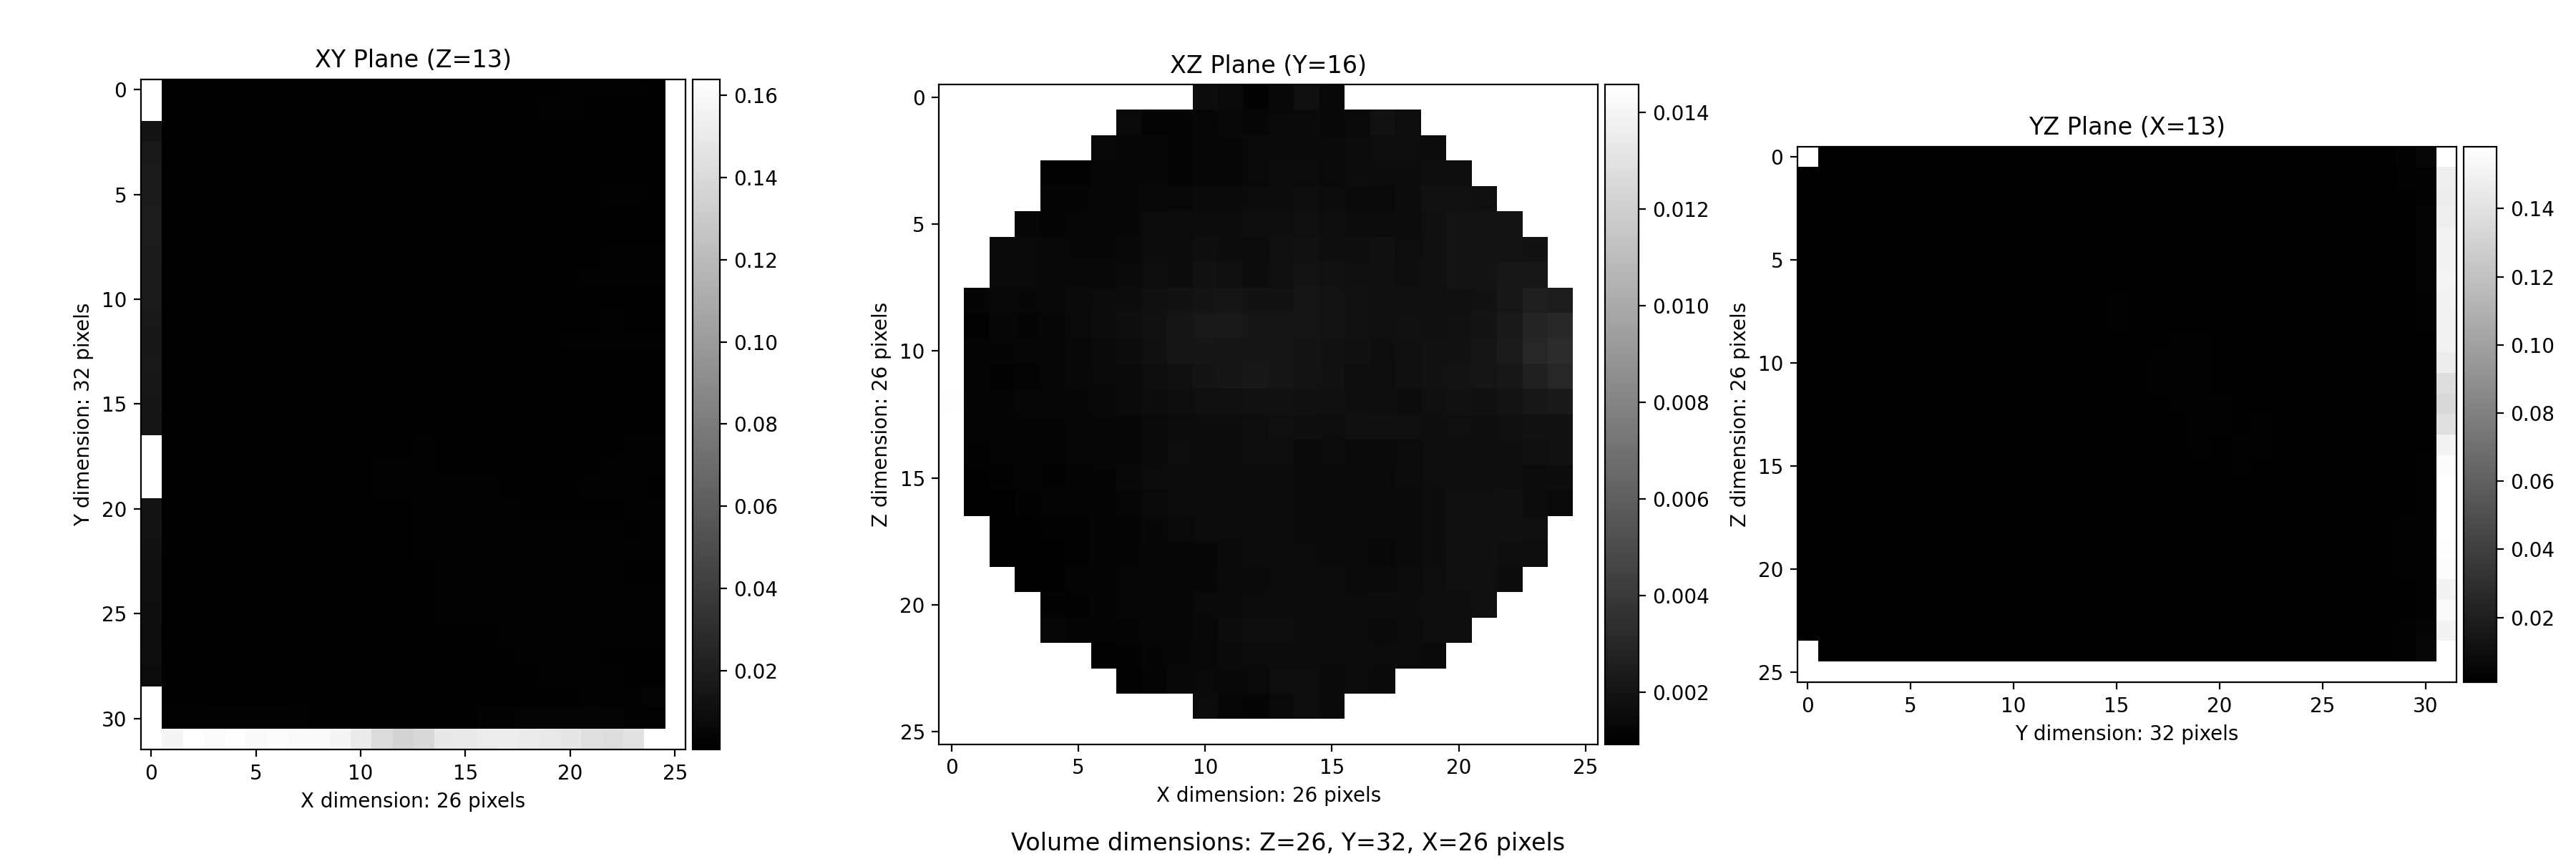

40hws_60ns_50it_63glt_3z-3y-3xm_G16060_K12_5_0_ref-G16060_K12_5_3_load.png


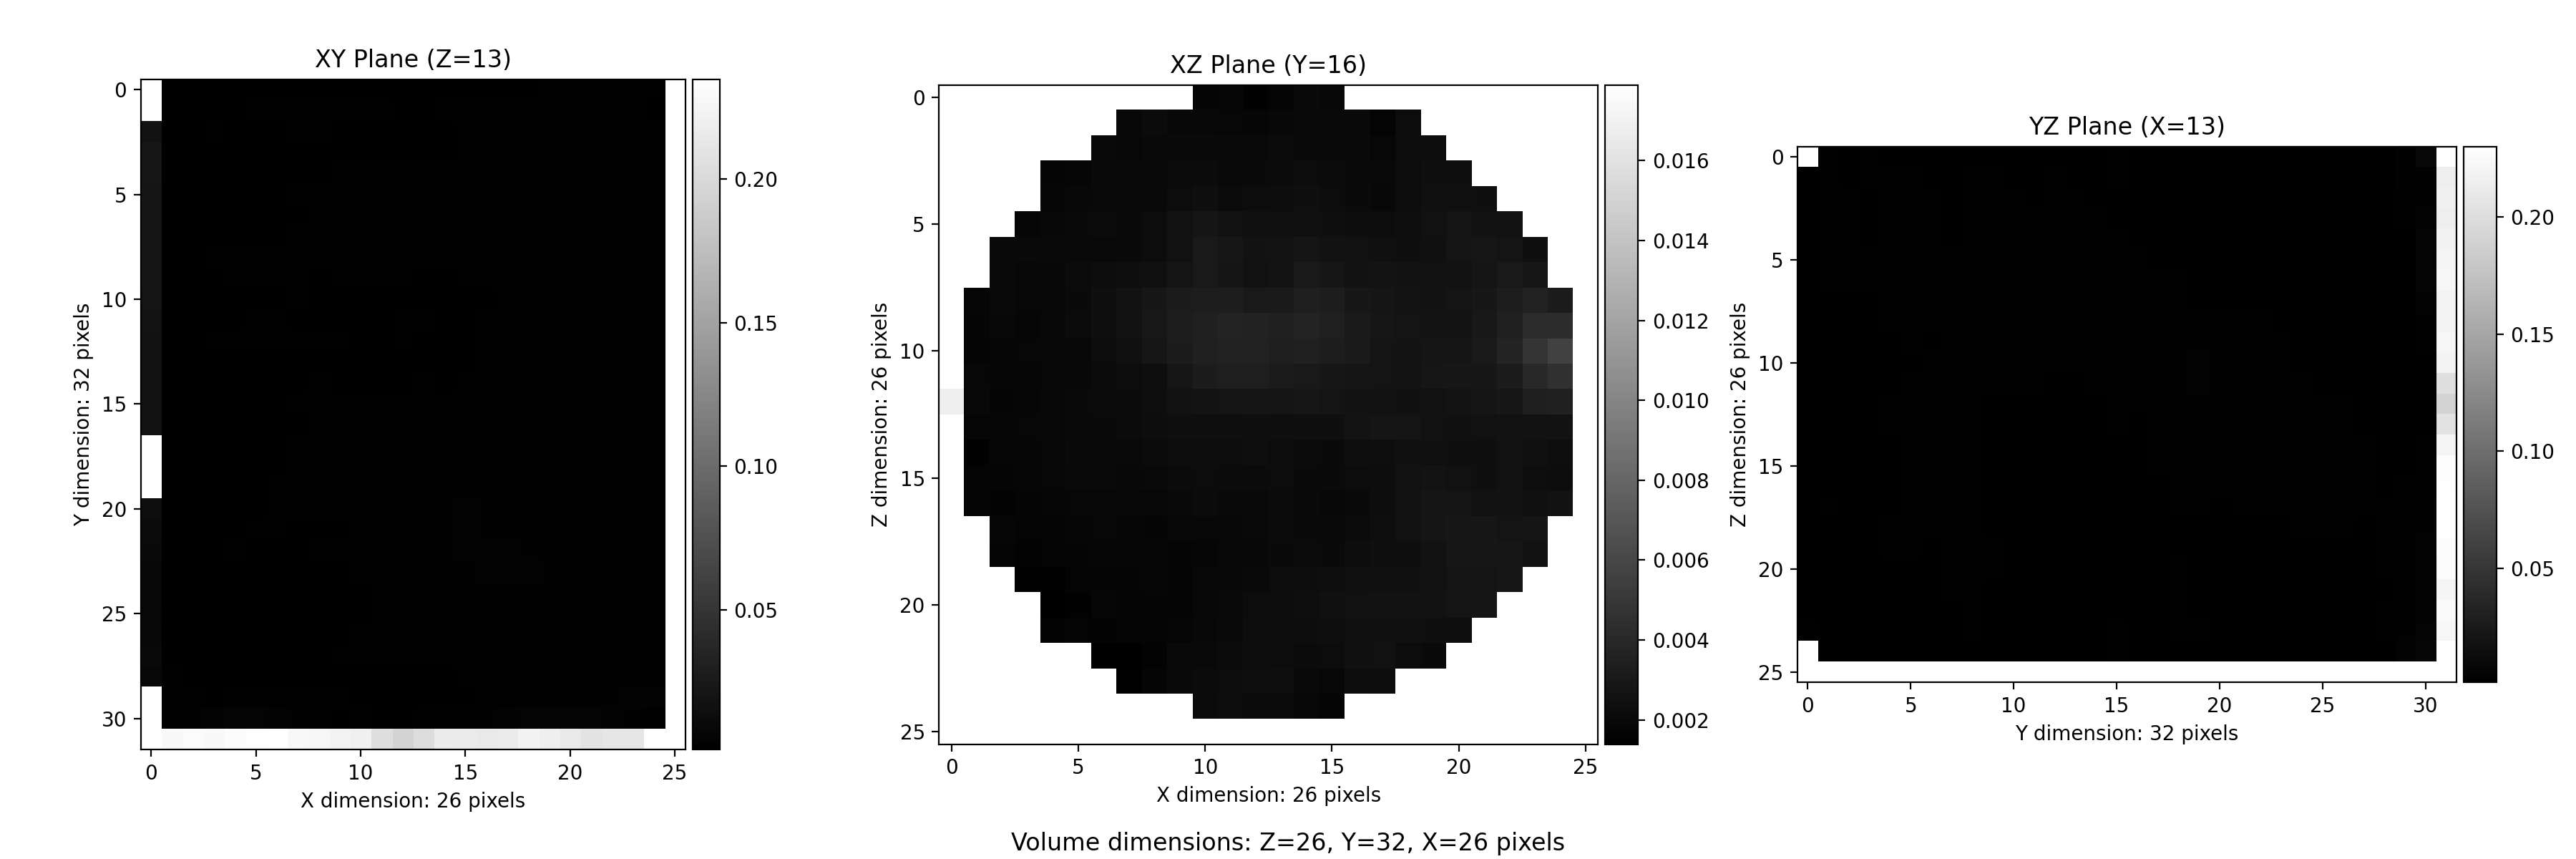

40hws_60ns_50it_63glt_3z-3y-3xm_G16060_K12_5_0_ref-G16060_K12_5_4_load.png


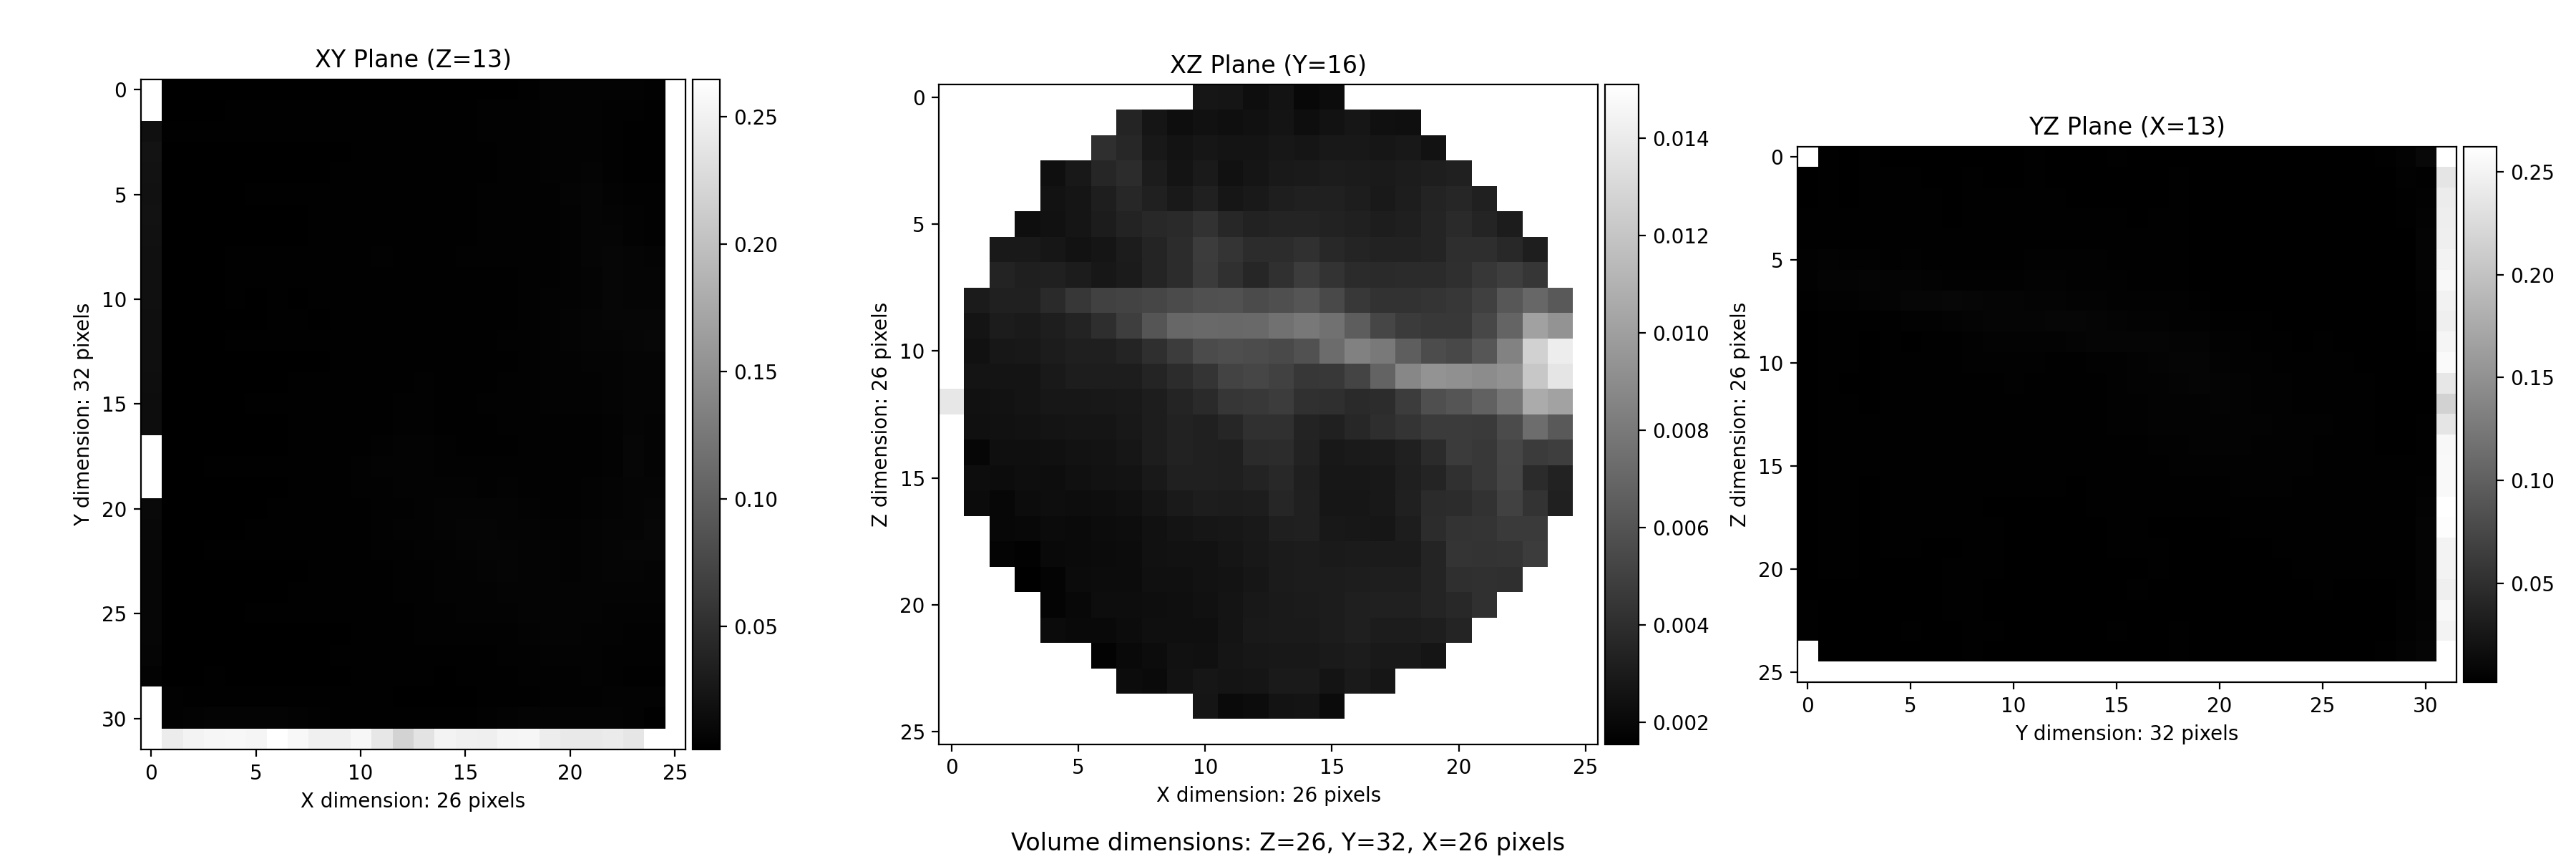

40hws_60ns_50it_48glt_3z-3y-3xm_G16060_P7_5_0_ref-G16060_P7_5_3_load.png


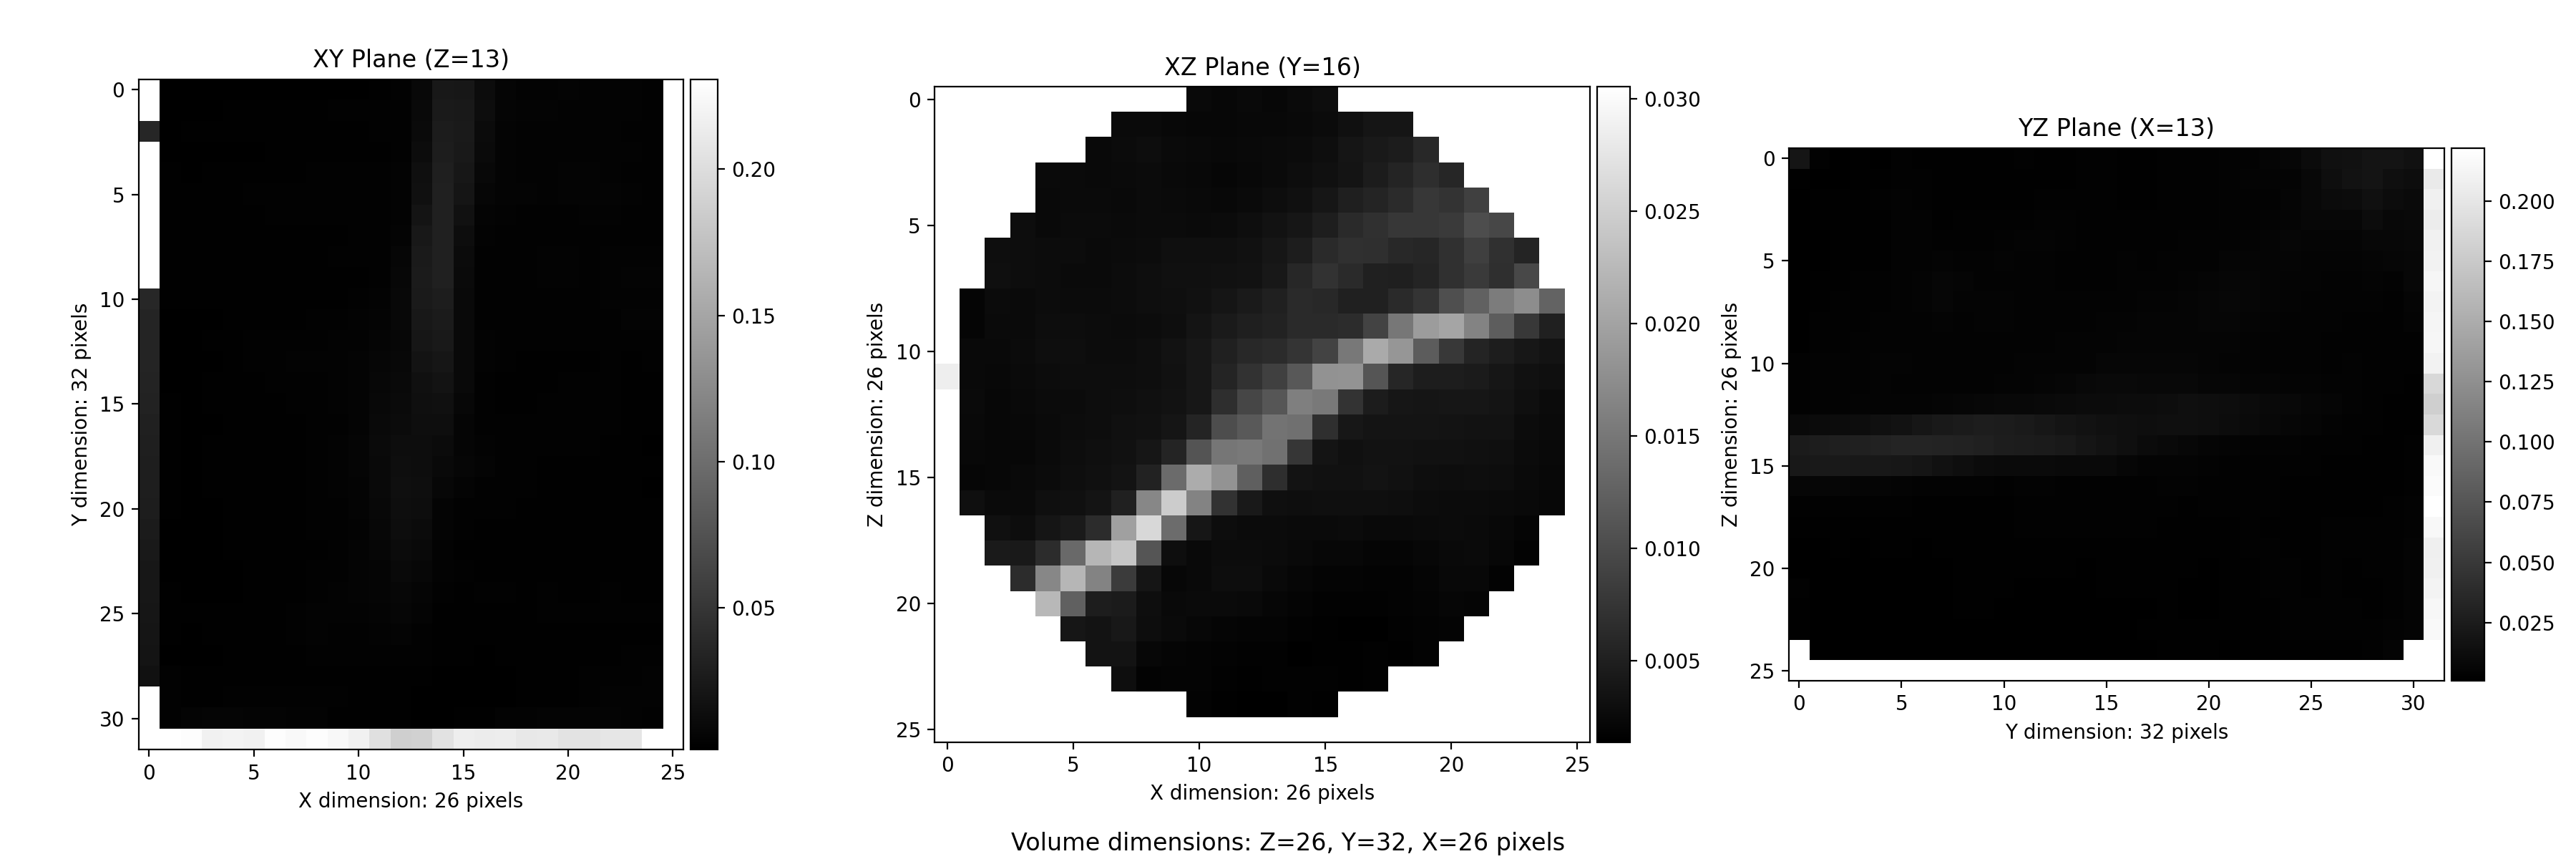

40hws_60ns_50it_48glt_3z-3y-3xm_G16060_P7_5_0_ref-G16060_P7_5_1_load.png


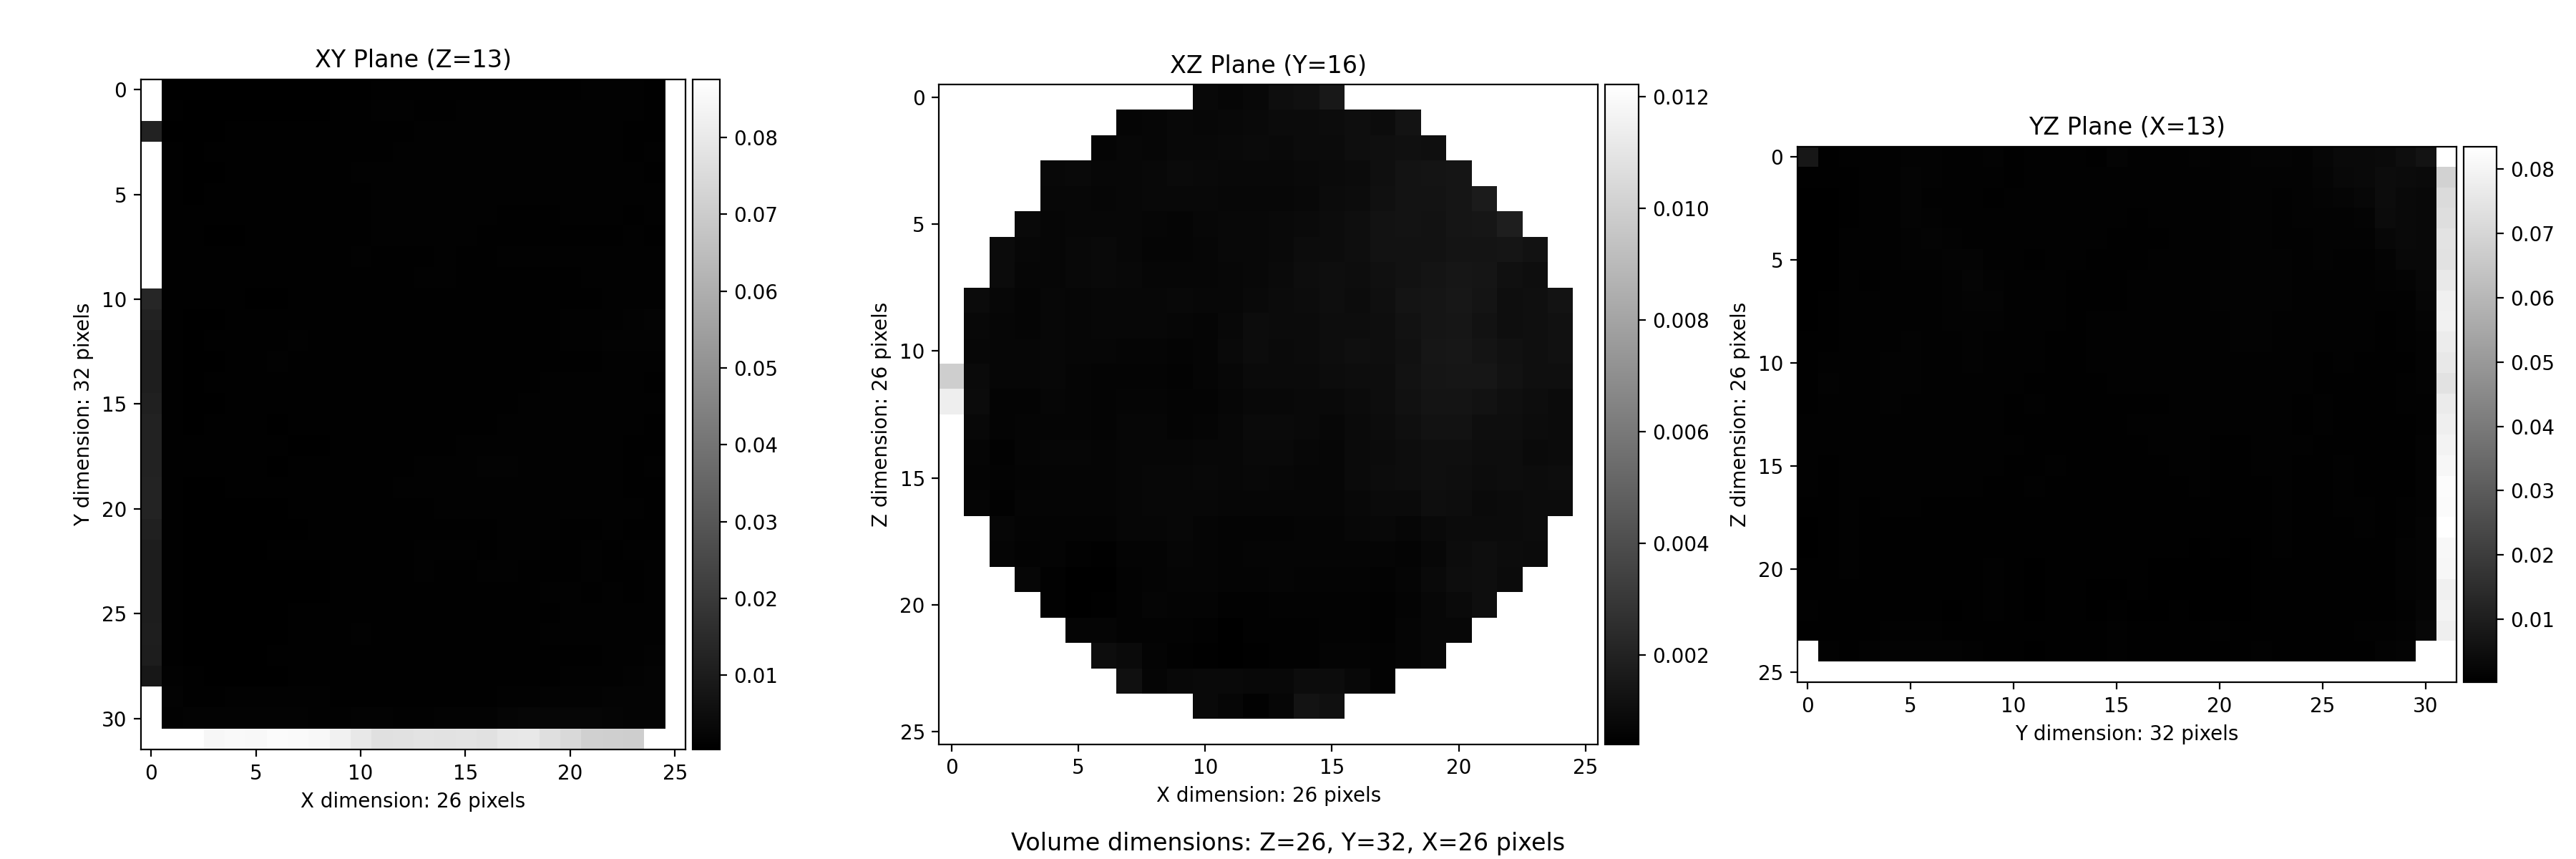

40hws_60ns_50it_48glt_3z-3y-3xm_G16060_P7_5_0_ref-G16060_P7_5_2_load.png


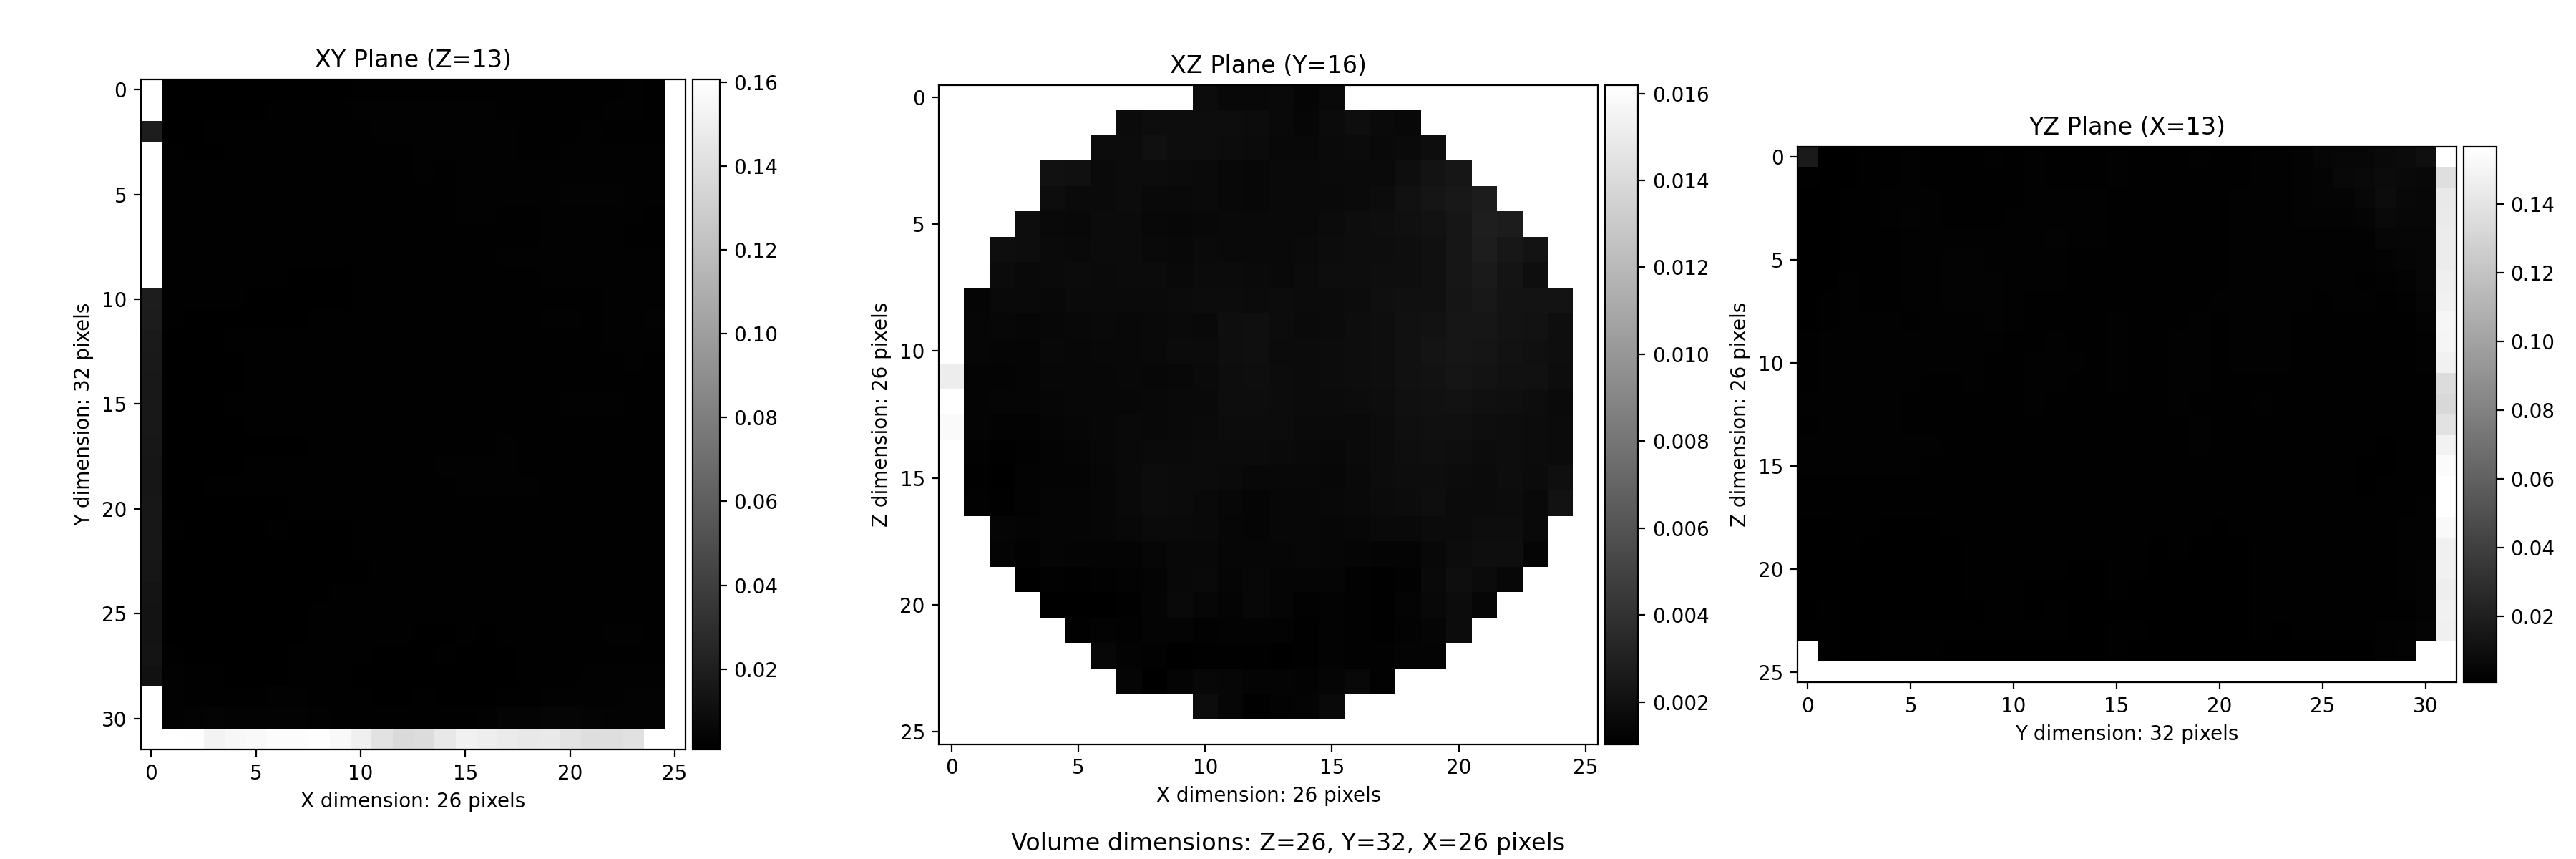

In [19]:
# go through every folder in dvc_output_path
# find the strain_filtered_path folder
# find a .png file
# open it and display it

import PIL.Image as Image

for folder in os.listdir(dvc_output_path):
    p = os.path.join(dvc_output_path, folder)
    for file in os.listdir(p):
        if file.endswith(strain_filtered_path):
            p = os.path.join(dvc_output_path, folder, file)
            for f in os.listdir(p):
                if f.endswith(".png"):
                    p = os.path.join(p, f)
                    img = Image.open(p)
                    if "40hws_60ns" in os.path.basename(p):
                        print(os.path.basename(p))
                        display(Image.open(p))

In [8]:
load_num = 3
im1 = "res/p_ref/ref.tif"
im2 = f"res/p_{load_num}_load/shifted_load.tif"

hws = 20
ns = 20
it = 50
glt = 66
out = f"results/ldic/p_{hws}hws_{ns}ns_{it}it_{glt}glt_shifted_load_{load_num}"

ldic = f'spam-ldic {im1} {im2} -hws {hws} -ns {ns} -it {it} -glt {glt} -vtk -tif -od {out}'

tsv_file = f'{out}/ref-shifted_load-ldic.tsv'
out_filter = f'{out}/filtered'

filter = f'spam-filterPhiField -pf {tsv_file} -fm -F "all" -tif -vtk -od {out_filter}'

out_strain = f"results/strain/p_{hws}hws_{ns}ns_{it}it_{glt}glt_shifted_filtered_{load_num}"
out_strain_no_filter = f"results/strain/p_{hws}hws_{ns}ns_{it}it_{glt}glt_shifted_{load_num}"

no_filter_strain = f'spam-regularStrain {tsv_file} -comp vol dev U -cub -tif -vtk -od {out_strain_no_filter}'
strain = f'spam-regularStrain {out_filter}/ref-shifted_load-ldic-filtered.tsv -comp vol dev U -cub -tif -vtk -od {out_strain} -rst 1'

In [ ]:
# !{ldic} # 20 min # 2h 46m - 20ns
# !{filter}
# !{strain}
!{no_filter_strain}